# Quantum-Inspired TON-IoT Analysis Notebook

This regenerated version is organized for reproducible execution in Google Colab with standardized artifact management.

1. **All generated artifacts are saved to Google Drive** using a structured folder layout:
   - `Outputs/Amal/figures`
   - `Outputs/Amal/tables`
   - `Outputs/Amal/others`
2. **Every executable Python cell is introduced by a short text cell** with a title and concise description.
3. **Key outputs are tracked in an artifact manifest** for easier reviewer inspection and repository packaging.

Run the notebook from top to bottom so each downstream stage can reuse the saved outputs produced earlier in the workflow.

### Environment Setup and Dataset Loading
Import the required libraries, mount Google Drive, define the shared output folders, and load the TON-IoT dataset from Google Drive. The notebook first tries the original dataset path used in your working version (`/content/drive/MyDrive/Datasets/Amal/ton-iot-train_test_network.csv`), then checks a few alternate paths, and finally searches Google Drive for common matching filenames before raising an error.

In [3]:
import warnings
warnings.filterwarnings("ignore")

import json
import hashlib
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score
)
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier

from google.colab import drive

# -------------------------------------------------------------------
# Google Drive mounting
# -------------------------------------------------------------------
DRIVE_MOUNT_POINT = "/content/drive"
drive.mount(DRIVE_MOUNT_POINT)

# -------------------------------------------------------------------
# Centralized Google Drive output structure
# -------------------------------------------------------------------
DRIVE_OUTPUT_DIR = Path("/content/drive/MyDrive/Outputs/Amal/MBZUAI-3")
FIG_DIR = DRIVE_OUTPUT_DIR / "figures"
TABLE_DIR = DRIVE_OUTPUT_DIR / "tables"
OTHER_DIR = DRIVE_OUTPUT_DIR / "others"

for d in [DRIVE_OUTPUT_DIR, FIG_DIR, TABLE_DIR, OTHER_DIR]:
    d.mkdir(parents=True, exist_ok=True)

RUN_TIMESTAMP = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
ARTIFACT_LOG = []

def log_artifact(path, artifact_type):
    path = Path(path)
    record = {
        "timestamp": RUN_TIMESTAMP,
        "type": artifact_type,
        "path": str(path)
    }
    ARTIFACT_LOG.append(record)
    print(f"[Saved {artifact_type}] {path}")
    return path

def save_figure(filename, dpi=300):
    path = FIG_DIR / filename
    plt.savefig(path, dpi=dpi, bbox_inches="tight")
    return log_artifact(path, "figure")

def save_table(df, filename, index=False):
    path = TABLE_DIR / filename
    df.to_csv(path, index=index)
    return log_artifact(path, "table")

def save_json(obj, filename):
    path = OTHER_DIR / filename
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=4)
    return log_artifact(path, "json")

def save_text(text, filename):
    path = OTHER_DIR / filename
    with open(path, "w", encoding="utf-8") as f:
        f.write(str(text))
    return log_artifact(path, "text")

def save_artifact_manifest():
    manifest_path = OTHER_DIR / "artifact_manifest.csv"
    pd.DataFrame(ARTIFACT_LOG).to_csv(manifest_path, index=False)
    print(f"[Saved manifest] {manifest_path}")
    return manifest_path

# -------------------------------------------------------------------
# Dataset discovery
# -------------------------------------------------------------------
def find_matching_files(filenames, root="/content/drive/MyDrive"):
    root = Path(root)
    if not root.exists():
        return []
    matches = []
    for name in filenames:
        matches.extend(root.rglob(name))
    # unique + sorted string path
    unique = sorted({str(m) for m in matches})
    return [Path(p) for p in unique]

def resolve_dataset_path():
    primary_candidates = [
        Path("/content/drive/MyDrive/Datasets/Amal/ton-iot-train_test_network.csv"),
        Path("/content/drive/MyDrive/Output_CSVs/Train_Test_IoT_Dataset.csv"),
        Path("/content/drive/MyDrive/Datasets/ton-iot-train_test_network.csv"),
        Path("/content/drive/MyDrive/ton-iot-train_test_network.csv"),
    ]

    for candidate in primary_candidates:
        if candidate.exists():
            print(f"Using dataset at: {candidate}")
            return candidate

    print("Primary dataset paths not found.")
    print("Searching Google Drive for a matching file name...")

    candidate_names = [
        "ton-iot-train_test_network.csv",
        "Train_Test_IoT_Dataset.csv",
    ]
    matches = find_matching_files(candidate_names)

    if matches:
        print("Candidate dataset files found:")
        for idx, match in enumerate(matches[:10], start=1):
            print(f"  {idx}. {match}")
        chosen = matches[0]
        print(f"Using first match: {chosen}")
        return chosen

    searched_root = Path("/content/drive/MyDrive")
    raise FileNotFoundError(
        "Could not find the TON-IoT dataset in Google Drive. "
        "Expected one of these names: "
        "'ton-iot-train_test_network.csv' or 'Train_Test_IoT_Dataset.csv'. "
        f"Please upload or place the file somewhere under {searched_root}."
    )

print("Output structure:")
print(f"Base folder : {DRIVE_OUTPUT_DIR}")
print(f"Figures     : {FIG_DIR}")
print(f"Tables      : {TABLE_DIR}")
print(f"Other files : {OTHER_DIR}")

DATA_PATH = resolve_dataset_path()
df_raw = pd.read_csv(DATA_PATH)

print(f"Loaded dataset from: {DATA_PATH}")
print(f"Dataset shape: {df_raw.shape}")
display(df_raw.head())

dataset_snapshot_path = save_table(df_raw, "loaded_dataset_snapshot.csv", index=False)
save_text(str(DATA_PATH), "resolved_dataset_path.txt")
print(f"Saved dataset snapshot to: {dataset_snapshot_path}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Output structure:
Base folder : /content/drive/MyDrive/Outputs/Amal/MBZUAI-3
Figures     : /content/drive/MyDrive/Outputs/Amal/MBZUAI-3/figures
Tables      : /content/drive/MyDrive/Outputs/Amal/MBZUAI-3/tables
Other files : /content/drive/MyDrive/Outputs/Amal/MBZUAI-3/others
Using dataset at: /content/drive/MyDrive/Datasets/Amal/ton-iot-train_test_network.csv
Loaded dataset from: /content/drive/MyDrive/Datasets/Amal/ton-iot-train_test_network.csv
Dataset shape: (211043, 44)


,src_ip,src_port,dst_ip,dst_port,proto,service,duration,src_bytes,dst_bytes,conn_state,...,http_response_body_len,http_status_code,http_user_agent,http_orig_mime_types,http_resp_mime_types,weird_name,weird_addl,weird_notice,label,type
0,192.168.1.37,4444,192.168.1.193,49178,tcp,-,290.371539,101568,2592,OTH,...,0,0,-,-,-,-,-,-,1,backdoor
1,192.168.1.193,49180,192.168.1.37,8080,tcp,-,0.000102,0,0,REJ,...,0,0,-,-,-,-,-,-,1,backdoor
2,192.168.1.193,49180,192.168.1.37,8080,tcp,-,0.000148,0,0,REJ,...,0,0,-,-,-,-,-,-,1,backdoor
3,192.168.1.193,49180,192.168.1.37,8080,tcp,-,0.000113,0,0,REJ,...,0,0,-,-,-,-,-,-,1,backdoor
4,192.168.1.193,49180,192.168.1.37,8080,tcp,-,0.000130,0,0,REJ,...,0,0,-,-,-,-,-,-,1,backdoor


[Saved table] /content/drive/MyDrive/Outputs/Amal/MBZUAI-3/tables/loaded_dataset_snapshot.csv
[Saved text] /content/drive/MyDrive/Outputs/Amal/MBZUAI-3/others/resolved_dataset_path.txt
Saved dataset snapshot to: /content/drive/MyDrive/Outputs/Amal/MBZUAI-3/tables/loaded_dataset_snapshot.csv


### Initial Data Cleaning
Remove duplicate rows and normalize common missing-value tokens to prepare the raw dataset for analysis.

In [4]:
df = df_raw.copy()

missing_tokens = ["-", "?", "NA", "N/A", "None", "none", ""]
df.replace(missing_tokens, np.nan, inplace=True)

print("Shape before duplicate removal:", df.shape)
print("Duplicate rows before removal:", df.duplicated().sum())

df = df.drop_duplicates().reset_index(drop=True)

print("Shape after duplicate removal:", df.shape)
print("Duplicate rows after removal:", df.duplicated().sum())

Shape before duplicate removal: (211043, 44)
Duplicate rows before removal: 20569
Shape after duplicate removal: (190474, 44)
Duplicate rows after removal: 0


### Binary Label Construction
Convert the original label field into a clean binary target and inspect the class and attack-type distributions.

In [5]:
def normalize_label(x):
    s = str(x).strip().lower()
    if s in ["0", "benign", "normal"]:
        return 0
    return 1

df["label_binary"] = df["label"].apply(normalize_label)

print("Binary label distribution:")
display(df["label_binary"].value_counts())

print("\nAttack-type distribution:")
display(df["type"].value_counts())

Binary label distribution:


,count
label_binary,
1,148434
0,42040



Attack-type distribution:


,count
type,
normal,42040
scanning,20000
ddos,19993
injection,19964
password,19861
dos,18992
backdoor,18711
xss,15137
ransomware,14735


### Event Identifier Assignment
Create a stable event index so that later temporal and graph-based stages can reference each observation consistently.

In [6]:
df = df.reset_index(drop=True).copy()
df["event_id"] = np.arange(len(df))

print("Final cleaned dataset shape:", df.shape)
display(df[["event_id", "label", "label_binary", "type"]].head())

Final cleaned dataset shape: (190474, 46)


,event_id,label,label_binary,type
0,0,1,1,backdoor
1,1,1,1,backdoor
2,2,1,1,backdoor
3,3,1,1,backdoor
4,4,1,1,backdoor


### Feature Selection and Leakage Control
Define the prediction target, remove explicit label columns, and exclude leakage-prone network identifiers from the baseline model.

In [7]:
target_col = "label_binary"

exclude_cols = ["label", "label_binary", "type", "event_id"]
leakage_prone_cols = ["src_ip", "src_port", "dst_ip", "dst_port"]

feature_cols_all = [c for c in df.columns if c not in exclude_cols]
ml_feature_cols = [c for c in feature_cols_all if c not in leakage_prone_cols]

categorical_cols_ml = [c for c in ml_feature_cols if df[c].dtype == "object"]
numeric_cols_ml = [c for c in ml_feature_cols if c not in categorical_cols_ml]

print("Total ML feature columns:", len(ml_feature_cols))
print("Numeric ML columns:", len(numeric_cols_ml))
print("Categorical ML columns:", len(categorical_cols_ml))

print("\nCategorical ML columns:")
print(categorical_cols_ml)

print("\nNumeric ML columns:")
print(numeric_cols_ml)

Total ML feature columns: 38
Numeric ML columns: 14
Categorical ML columns: 24

Categorical ML columns:
['proto', 'service', 'conn_state', 'dns_query', 'dns_AA', 'dns_RD', 'dns_RA', 'dns_rejected', 'ssl_version', 'ssl_cipher', 'ssl_resumed', 'ssl_established', 'ssl_subject', 'ssl_issuer', 'http_trans_depth', 'http_method', 'http_uri', 'http_version', 'http_user_agent', 'http_orig_mime_types', 'http_resp_mime_types', 'weird_name', 'weird_addl', 'weird_notice']

Numeric ML columns:
['duration', 'src_bytes', 'dst_bytes', 'missed_bytes', 'src_pkts', 'src_ip_bytes', 'dst_pkts', 'dst_ip_bytes', 'dns_qclass', 'dns_qtype', 'dns_rcode', 'http_request_body_len', 'http_response_body_len', 'http_status_code']


### Model Input Matrices
Assemble the feature matrix and target vector that will be used for the stage-one detection model.

In [8]:
X = df[ml_feature_cols].copy()
y = df[target_col].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)
display(y.value_counts(normalize=True))

X shape: (190474, 38)
y shape: (190474,)


,proportion
label_binary,
1,0.779287
0,0.220713


### Train, Validation, and Test Split
Partition the dataset into stratified subsets so model development and evaluation remain separated.

In [9]:
X_train_full, X_test, y_train_full, y_test, idx_train_full, idx_test = train_test_split(
    X, y, df.index,
    test_size=0.15,
    random_state=42,
    stratify=y
)

X_train, X_val, y_train, y_val, idx_train, idx_val = train_test_split(
    X_train_full, y_train_full, idx_train_full,
    test_size=0.1764705882,   # gives ~15% of total as validation
    random_state=42,
    stratify=y_train_full
)

print("Train shape:", X_train.shape, y_train.shape)
print("Val shape:", X_val.shape, y_val.shape)
print("Test shape:", X_test.shape, y_test.shape)

print("\nTrain class distribution:")
display(y_train.value_counts(normalize=True))

print("\nVal class distribution:")
display(y_val.value_counts(normalize=True))

print("\nTest class distribution:")
display(y_test.value_counts(normalize=True))

Train shape: (133331, 38) (133331,)
Val shape: (28571, 38) (28571,)
Test shape: (28572, 38) (28572,)

Train class distribution:


,proportion
label_binary,
1,0.779286
0,0.220714



Val class distribution:


,proportion
label_binary,
1,0.779287
0,0.220713



Test class distribution:


,proportion
label_binary,
1,0.779294
0,0.220706


### Tabular Preprocessing Pipeline
Create preprocessing steps for numeric and categorical variables before model training.

In [10]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols_ml),
        ("cat", categorical_transformer, categorical_cols_ml),
    ]
)

print("Preprocessor ready.")

Preprocessor ready.


### Baseline ExtraTrees Training
Train the first-stage ExtraTrees detector that scores each event for suspicious behavior.

In [11]:
et_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", ExtraTreesClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced"
    ))
])

et_pipeline.fit(X_train, y_train)
print("ExtraTrees baseline trained.")

ExtraTrees baseline trained.


### Validation Performance Assessment
Evaluate the stage-one detector on the validation split using threshold-based and ranking metrics.

In [ ]:
val_probs = et_pipeline.predict_proba(X_val)[:, 1]
val_preds = (val_probs >= 0.5).astype(int)

val_metrics = {
    "accuracy": accuracy_score(y_val, val_preds),
    "balanced_accuracy": balanced_accuracy_score(y_val, val_preds),
    "precision": precision_score(y_val, val_preds, zero_division=0),
    "recall": recall_score(y_val, val_preds, zero_division=0),
    "f1": f1_score(y_val, val_preds, zero_division=0),
    "roc_auc": roc_auc_score(y_val, val_probs),
    "avg_precision": average_precision_score(y_val, val_probs)
}

print("Validation metrics:")
for k, v in val_metrics.items():
    print(f"{k}: {v:.6f}")

print("\nValidation classification report:")
print(classification_report(y_val, val_preds, digits=4))

print("\nValidation confusion matrix:")
print(confusion_matrix(y_val, val_preds))

Validation metrics:
accuracy: 0.998600
balanced_accuracy: 0.997340
precision: 0.998609
recall: 0.999596
f1: 0.999102
roc_auc: 0.999548
avg_precision: 0.999751

Validation classification report:
              precision    recall  f1-score   support

           0     0.9986    0.9951    0.9968      6306
           1     0.9986    0.9996    0.9991     22265

    accuracy                         0.9986     28571
   macro avg     0.9986    0.9973    0.9980     28571
weighted avg     0.9986    0.9986    0.9986     28571


Validation confusion matrix:
[[ 6275    31]
 [    9 22256]]


### Test Performance Assessment
Measure the final stage-one detector on the held-out test set.

In [12]:
test_probs = et_pipeline.predict_proba(X_test)[:, 1]
test_preds = (test_probs >= 0.5).astype(int)

test_metrics = {
    "accuracy": accuracy_score(y_test, test_preds),
    "balanced_accuracy": balanced_accuracy_score(y_test, test_preds),
    "precision": precision_score(y_test, test_preds, zero_division=0),
    "recall": recall_score(y_test, test_preds, zero_division=0),
    "f1": f1_score(y_test, test_preds, zero_division=0),
    "roc_auc": roc_auc_score(y_test, test_probs),
    "avg_precision": average_precision_score(y_test, test_probs)
}

print("Test metrics:")
for k, v in test_metrics.items():
    print(f"{k}: {v:.6f}")

print("\nTest classification report:")
print(classification_report(y_test, test_preds, digits=4))

print("\nTest confusion matrix:")
print(confusion_matrix(y_test, test_preds))

Test metrics:
accuracy: 0.997900
balanced_accuracy: 0.996095
precision: 0.997982
recall: 0.999326
f1: 0.998654
roc_auc: 0.999725
avg_precision: 0.999851

Test classification report:
              precision    recall  f1-score   support

           0     0.9976    0.9929    0.9952      6306
           1     0.9980    0.9993    0.9987     22266

    accuracy                         0.9979     28572
   macro avg     0.9978    0.9961    0.9969     28572
weighted avg     0.9979    0.9979    0.9979     28572


Test confusion matrix:
[[ 6261    45]
 [   15 22251]]


### Scoring the Full Dataset
Apply the trained detector to the full dataset and attach event-level probabilities and predictions.

In [13]:
full_probs = et_pipeline.predict_proba(X)[:, 1]
full_preds = (full_probs >= 0.5).astype(int)

df_scored = df.copy()
df_scored["et_prob"] = full_probs
df_scored["et_pred"] = full_preds

print("Scored full dataset:", df_scored.shape)
display(df_scored[[
    "event_id", "src_ip", "src_port", "dst_ip", "dst_port",
    "label_binary", "type", "et_prob", "et_pred"
]].head(10))

Scored full dataset: (190474, 48)


,event_id,src_ip,src_port,dst_ip,dst_port,label_binary,type,et_prob,et_pred
0,0,192.168.1.37,4444,192.168.1.193,49178,1,backdoor,1.0,1
1,1,192.168.1.193,49180,192.168.1.37,8080,1,backdoor,1.0,1
2,2,192.168.1.193,49180,192.168.1.37,8080,1,backdoor,1.0,1
3,3,192.168.1.193,49180,192.168.1.37,8080,1,backdoor,1.0,1
4,4,192.168.1.193,49180,192.168.1.37,8080,1,backdoor,1.0,1
5,5,192.168.1.193,49180,192.168.1.37,8080,1,backdoor,1.0,1
6,6,192.168.1.193,49180,192.168.1.37,8080,1,backdoor,1.0,1
7,7,192.168.1.193,49180,192.168.1.37,8080,1,backdoor,1.0,1
8,8,192.168.1.193,49180,192.168.1.37,8080,1,backdoor,1.0,1
9,9,192.168.1.193,49180,192.168.1.37,8080,1,backdoor,1.0,1


### Attack-Level Summary Statistics
Aggregate the scored dataset by attack type to understand class-wise behavior and model confidence.

In [14]:
attack_summary = (
    df_scored.groupby("type")
    .agg(
        n_samples=("type", "size"),
        true_attack_rate=("label_binary", "mean"),
        predicted_attack_rate=("et_pred", "mean"),
        mean_attack_probability=("et_prob", "mean")
    )
    .sort_values("n_samples", ascending=False)
)

display(attack_summary)

,n_samples,true_attack_rate,predicted_attack_rate,mean_attack_probability
type,,,,
normal,42040,0.0,0.001974,0.002334
scanning,20000,1.0,1.000000,0.999880
ddos,19993,1.0,0.999900,0.999751
injection,19964,1.0,0.999800,0.999715
password,19861,1.0,1.000000,0.999856
dos,18992,1.0,0.999684,0.999425
backdoor,18711,1.0,1.000000,0.999940
xss,15137,1.0,0.999934,0.999344
ransomware,14735,1.0,0.998100,0.997336


### Save Stage-One Outputs
Write the scored stage-one dataset to Google Drive for reuse in later notebook stages.

In [15]:
OUTPUT_PATH = save_table(df_scored, "ton_iot_scored_stage1_corrected.csv", index=False)
print(f"Saved corrected stage-1 scored file to: {OUTPUT_PATH}")

[Saved table] /content/drive/MyDrive/Outputs/Amal/MBZUAI-3/tables/ton_iot_scored_stage1_corrected.csv
Saved corrected stage-1 scored file to: /content/drive/MyDrive/Outputs/Amal/MBZUAI-3/tables/ton_iot_scored_stage1_corrected.csv


## Stage 2 — Graph Construction and Temporal Campaign
This section transitions from event-level detection to graph-based analysis built on high-confidence suspicious events.

### Graph Pipeline Overview
The next cells define suspicious events, create event-order windows, build window-level interaction graphs, summarize their evolution, and prepare predictive graph features.

The graph stage starts from the saved scored dataset and progressively constructs a defensible temporal interaction pipeline.

### Graph Analysis Setup
Import graph-analysis libraries and reload the scored stage-one dataset from Google Drive.

In [16]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

df_scored = pd.read_csv(TABLE_DIR / "ton_iot_scored_stage1_corrected.csv")

print("Loaded scored dataset:", df_scored.shape)
display(df_scored.head())

Loaded scored dataset: (190474, 48)


,src_ip,src_port,dst_ip,dst_port,proto,service,duration,src_bytes,dst_bytes,conn_state,...,http_resp_mime_types,weird_name,weird_addl,weird_notice,label,type,label_binary,event_id,et_prob,et_pred
0,192.168.1.37,4444,192.168.1.193,49178,tcp,NaN,290.371539,101568,2592,OTH,...,NaN,NaN,NaN,NaN,1,backdoor,1,0,1.0,1
1,192.168.1.193,49180,192.168.1.37,8080,tcp,NaN,0.000102,0,0,REJ,...,NaN,NaN,NaN,NaN,1,backdoor,1,1,1.0,1
2,192.168.1.193,49180,192.168.1.37,8080,tcp,NaN,0.000148,0,0,REJ,...,NaN,NaN,NaN,NaN,1,backdoor,1,2,1.0,1
3,192.168.1.193,49180,192.168.1.37,8080,tcp,NaN,0.000113,0,0,REJ,...,NaN,NaN,NaN,NaN,1,backdoor,1,3,1.0,1
4,192.168.1.193,49180,192.168.1.37,8080,tcp,NaN,0.000130,0,0,REJ,...,NaN,NaN,NaN,NaN,1,backdoor,1,4,1.0,1


### Suspicious Event Filtering
Keep only high-confidence suspicious events to build a more defensible graph-analysis stage.

In [17]:
SUSPICION_THRESHOLD = 0.90

suspicious_df = df_scored[df_scored["et_prob"] >= SUSPICION_THRESHOLD].copy()

print("Total events:", len(df_scored))
print("Suspicious events:", len(suspicious_df))
print("Suspicious fraction:", len(suspicious_df) / len(df_scored))

print("\nAttack-type distribution in suspicious events:")
display(suspicious_df["type"].value_counts())

Total events: 190474
Suspicious events: 148284
Suspicious fraction: 0.7784999527494566

Attack-type distribution in suspicious events:


,count
type,
scanning,19993
ddos,19983
injection,19954
password,19851
dos,18967
backdoor,18708
xss,15117
ransomware,14673
mitm,1011


### Node and Edge Key Engineering
Construct node identifiers and edge keys that will be used to define graph interactions.

In [18]:
suspicious_df["edge_key"] = (
    suspicious_df["src_ip"].astype(str) + ":" + suspicious_df["src_port"].astype(str)
    + " -> " +
    suspicious_df["dst_ip"].astype(str) + ":" + suspicious_df["dst_port"].astype(str)
)

suspicious_df["src_node"] = suspicious_df["src_ip"].astype(str)
suspicious_df["dst_node"] = suspicious_df["dst_ip"].astype(str)

print("Unique suspicious source nodes:", suspicious_df["src_node"].nunique())
print("Unique suspicious destination nodes:", suspicious_df["dst_node"].nunique())
print("Unique suspicious edges:", suspicious_df["edge_key"].nunique())

Unique suspicious source nodes: 18
Unique suspicious destination nodes: 239
Unique suspicious edges: 94303


### Pseudo-Temporal Windowing
Assign windows on the **full event stream** rather than only on suspicious events. This avoids the artificial saturation caused by fixed-size windows over already-filtered suspicious events and produces more realistic variation in suspicious-event counts across windows.


In [19]:
WINDOW_SIZE = 1000

# Assign windows on the full ordered event stream first
df_scored = df_scored.sort_values("event_id").reset_index(drop=True).copy()
df_scored["window_id"] = df_scored.index // WINDOW_SIZE

# Harmonize node identifiers on the full stream
if "src_node" not in df_scored.columns:
    if "src_ip" in df_scored.columns:
        df_scored["src_node"] = df_scored["src_ip"].astype(str)
    else:
        raise KeyError("Neither 'src_node' nor 'src_ip' exists in df_scored.")

if "dst_node" not in df_scored.columns:
    if "dst_ip" in df_scored.columns:
        df_scored["dst_node"] = df_scored["dst_ip"].astype(str)
    else:
        raise KeyError("Neither 'dst_node' nor 'dst_ip' exists in df_scored.")

# Create edge keys on the full stream so downstream subsets inherit them safely
if "edge_key" not in df_scored.columns:
    src_port_col = "src_port" if "src_port" in df_scored.columns else None
    dst_port_col = "dst_port" if "dst_port" in df_scored.columns else None

    if src_port_col is not None and dst_port_col is not None:
        df_scored["edge_key"] = (
            df_scored["src_node"].astype(str) + ":" + df_scored[src_port_col].astype(str)
            + " -> " +
            df_scored["dst_node"].astype(str) + ":" + df_scored[dst_port_col].astype(str)
        )
    else:
        df_scored["edge_key"] = (
            df_scored["src_node"].astype(str) + " -> " + df_scored["dst_node"].astype(str)
        )

# Then keep suspicious events while preserving the inherited window structure
suspicious_df = df_scored[df_scored["et_prob"] >= SUSPICION_THRESHOLD].copy()

print("Total events in full stream:", len(df_scored))
print("Suspicious events after thresholding:", len(suspicious_df))
print("Full-stream windows:", df_scored["window_id"].nunique())
print("Windows containing suspicious events:", suspicious_df["window_id"].nunique())
print("Window size (full stream):", WINDOW_SIZE)

display(
    suspicious_df[["event_id", "window_id", "src_node", "dst_node", "type", "et_prob"]]
    .head(10)
)

Total events in full stream: 190474
Suspicious events after thresholding: 148284
Full-stream windows: 191
Windows containing suspicious events: 161
Window size (full stream): 1000


,event_id,window_id,src_node,dst_node,type,et_prob
0,0,0,192.168.1.37,192.168.1.193,backdoor,1.0
1,1,0,192.168.1.193,192.168.1.37,backdoor,1.0
2,2,0,192.168.1.193,192.168.1.37,backdoor,1.0
3,3,0,192.168.1.193,192.168.1.37,backdoor,1.0
4,4,0,192.168.1.193,192.168.1.37,backdoor,1.0
5,5,0,192.168.1.193,192.168.1.37,backdoor,1.0
6,6,0,192.168.1.193,192.168.1.37,backdoor,1.0
7,7,0,192.168.1.193,192.168.1.37,backdoor,1.0
8,8,0,192.168.1.193,192.168.1.37,backdoor,1.0
9,9,0,192.168.1.193,192.168.1.37,backdoor,1.0


### Window-Level Summary Table
Compute per-window suspicious-event statistics after inheriting windows from the full traffic stream. The summary includes suspicious-event volume, edge diversity, mean risk, and suspicious-event rate within each full-stream window.


In [20]:
window_summary = (
    suspicious_df.groupby("window_id")
    .agg(
        n_events=("event_id", "size"),
        n_src_nodes=("src_node", "nunique"),
        n_dst_nodes=("dst_node", "nunique"),
        n_edges=("edge_key", "nunique"),
        mean_prob=("et_prob", "mean"),
        dominant_type=("type", lambda x: x.value_counts().index[0] if len(x) else "unknown")
    )
    .reset_index()
)

full_window_counts = (
    df_scored.groupby("window_id")
    .agg(total_events=("event_id", "size"))
    .reset_index()
)

window_summary = window_summary.merge(full_window_counts, on="window_id", how="left")
window_summary["suspicious_rate"] = window_summary["n_events"] / window_summary["total_events"].clip(lower=1)
window_summary["normalized_event_volume"] = window_summary["n_events"] / window_summary["total_events"].clip(lower=1)

print("Window summary shape:", window_summary.shape)
display(window_summary.head(15))

Window summary shape: (161, 10)


,window_id,n_events,n_src_nodes,n_dst_nodes,n_edges,mean_prob,dominant_type,total_events,suspicious_rate,normalized_event_volume
0,0,997,3,4,160,0.999672,backdoor,1000,0.997,0.997
1,1,1000,3,5,65,1.000000,backdoor,1000,1.000,1.000
2,2,1000,1,2,36,1.000000,backdoor,1000,1.000,1.000
3,3,1000,1,2,38,1.000000,backdoor,1000,1.000,1.000
4,4,1000,1,2,37,1.000000,backdoor,1000,1.000,1.000
5,5,1000,1,2,37,1.000000,backdoor,1000,1.000,1.000
6,6,1000,1,2,38,1.000000,backdoor,1000,1.000,1.000
7,7,1000,1,2,37,1.000000,backdoor,1000,1.000,1.000
8,8,1000,1,2,37,1.000000,backdoor,1000,1.000,1.000
9,9,1000,3,4,40,1.000000,backdoor,1000,1.000,1.000


### Temporal Volume, Diversity, and Rate Diagnostics
Plot the main pseudo-temporal diagnostics. In addition to raw counts, the notebook now records a normalized event-volume metric so the interpretation is not dominated by the fixed window size.

[Saved figure] /content/drive/MyDrive/Outputs/Amal/MBZUAI-3/figures/suspicious_event_volume_across_windows.png
Saved figure to: /content/drive/MyDrive/Outputs/Amal/MBZUAI-3/figures/suspicious_event_volume_across_windows.png


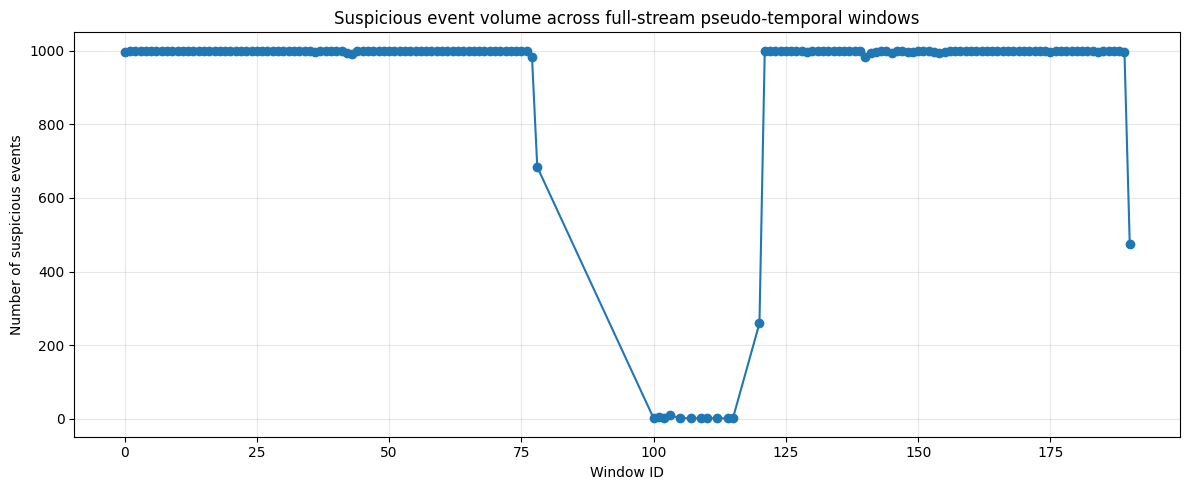

[Saved figure] /content/drive/MyDrive/Outputs/Amal/MBZUAI-3/figures/normalized_suspicious_event_volume_across_windows.png
Saved figure to: /content/drive/MyDrive/Outputs/Amal/MBZUAI-3/figures/normalized_suspicious_event_volume_across_windows.png


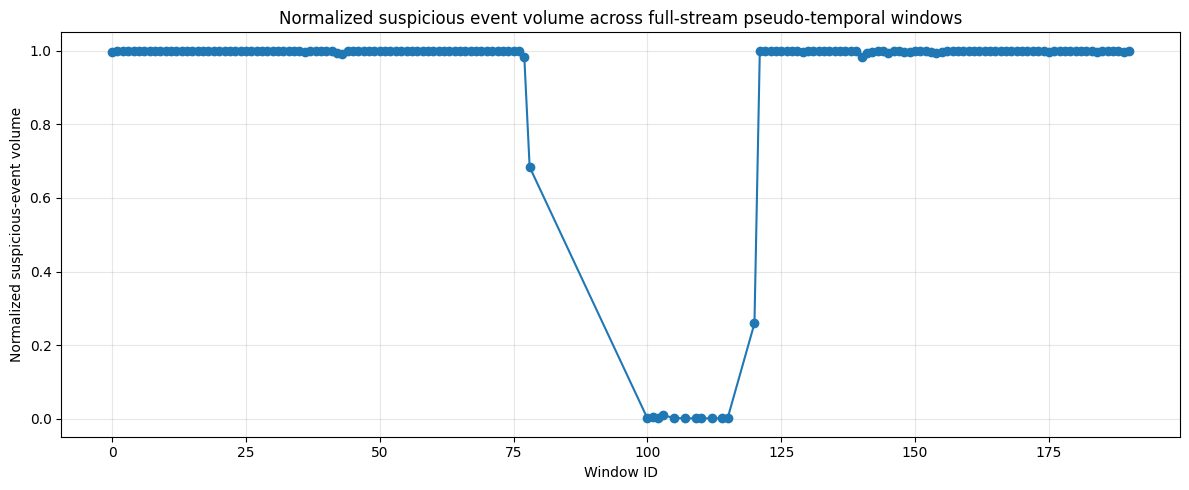

[Saved figure] /content/drive/MyDrive/Outputs/Amal/MBZUAI-3/figures/suspicious_edge_diversity_across_windows.png
Saved figure to: /content/drive/MyDrive/Outputs/Amal/MBZUAI-3/figures/suspicious_edge_diversity_across_windows.png


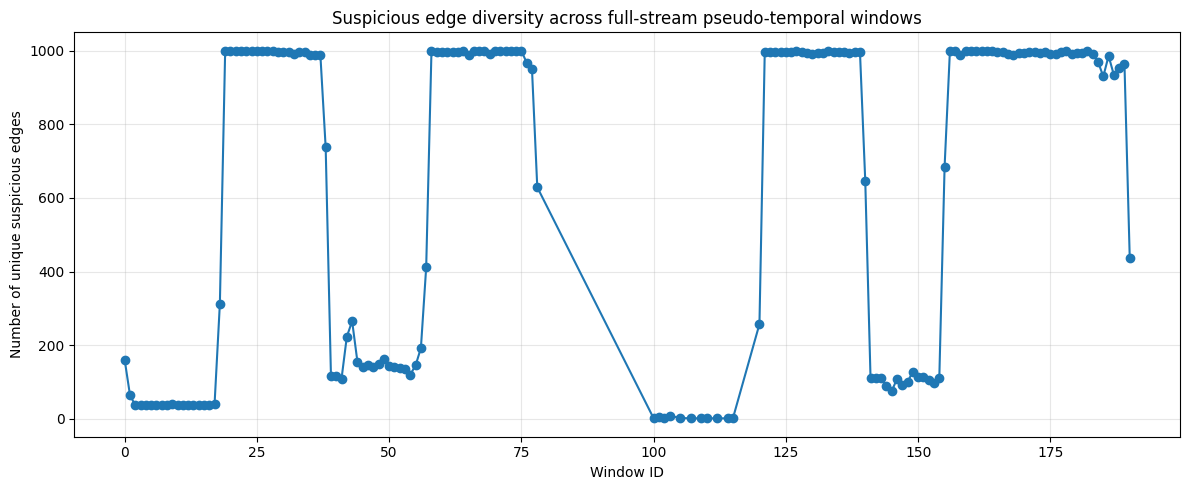

[Saved figure] /content/drive/MyDrive/Outputs/Amal/MBZUAI-3/figures/suspicious_event_rate_across_windows.png
Saved figure to: /content/drive/MyDrive/Outputs/Amal/MBZUAI-3/figures/suspicious_event_rate_across_windows.png


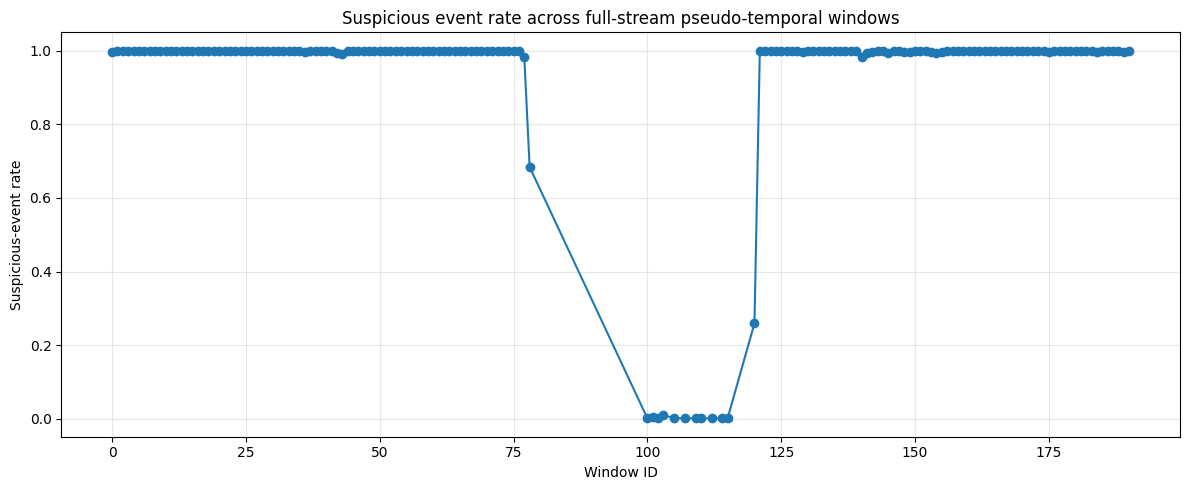

In [21]:
plt.figure(figsize=(12, 5))
plt.plot(window_summary["window_id"], window_summary["n_events"], marker="o")
plt.xlabel("Window ID")
plt.ylabel("Number of suspicious events")
plt.title("Suspicious event volume across full-stream pseudo-temporal windows")
plt.grid(alpha=0.3)
plt.tight_layout()
window_events_plot_path = save_figure("suspicious_event_volume_across_windows.png")
print(f"Saved figure to: {window_events_plot_path}")
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(window_summary["window_id"], window_summary["normalized_event_volume"], marker="o")
plt.xlabel("Window ID")
plt.ylabel("Normalized suspicious-event volume")
plt.title("Normalized suspicious event volume across full-stream pseudo-temporal windows")
plt.grid(alpha=0.3)
plt.tight_layout()
window_norm_events_plot_path = save_figure("normalized_suspicious_event_volume_across_windows.png")
print(f"Saved figure to: {window_norm_events_plot_path}")
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(window_summary["window_id"], window_summary["n_edges"], marker="o")
plt.xlabel("Window ID")
plt.ylabel("Number of unique suspicious edges")
plt.title("Suspicious edge diversity across full-stream pseudo-temporal windows")
plt.grid(alpha=0.3)
plt.tight_layout()
window_edges_plot_path = save_figure("suspicious_edge_diversity_across_windows.png")
print(f"Saved figure to: {window_edges_plot_path}")
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(window_summary["window_id"], window_summary["suspicious_rate"], marker="o")
plt.xlabel("Window ID")
plt.ylabel("Suspicious-event rate")
plt.title("Suspicious event rate across full-stream pseudo-temporal windows")
plt.grid(alpha=0.3)
plt.tight_layout()
window_rate_plot_path = save_figure("suspicious_event_rate_across_windows.png")
print(f"Saved figure to: {window_rate_plot_path}")
plt.show()

### Smoothed Temporal Trend Visualization
Apply light Gaussian smoothing to the edge-diversity and suspicious-rate trajectories to emphasize regime changes while reducing local oscillations caused by individual windows.

[Saved figure] /content/drive/MyDrive/Outputs/Amal/MBZUAI-3/figures/smoothed_suspicious_edge_diversity_across_windows.png
Saved figure to: /content/drive/MyDrive/Outputs/Amal/MBZUAI-3/figures/smoothed_suspicious_edge_diversity_across_windows.png


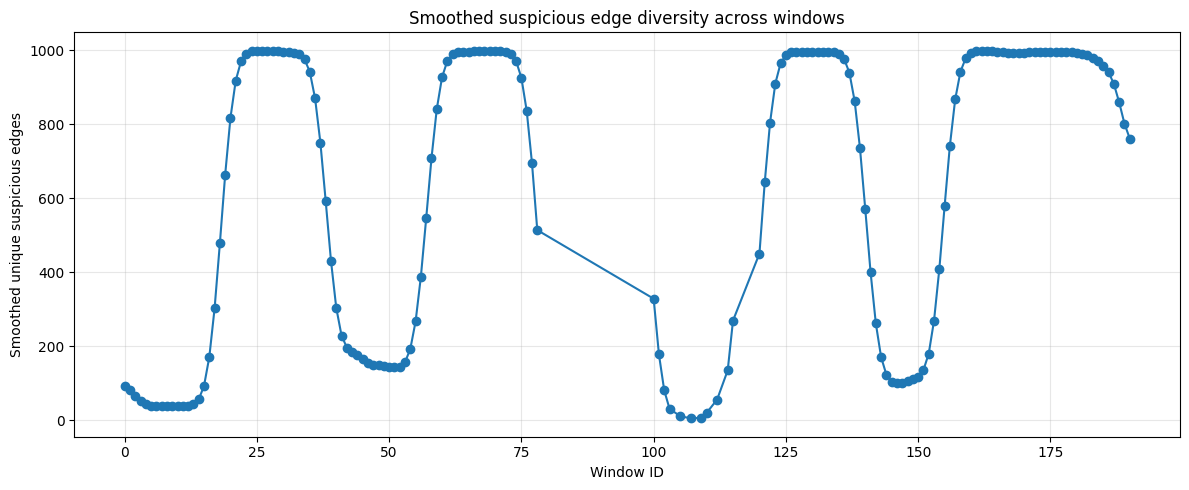

[Saved figure] /content/drive/MyDrive/Outputs/Amal/MBZUAI-3/figures/smoothed_suspicious_event_rate_across_windows.png
Saved figure to: /content/drive/MyDrive/Outputs/Amal/MBZUAI-3/figures/smoothed_suspicious_event_rate_across_windows.png


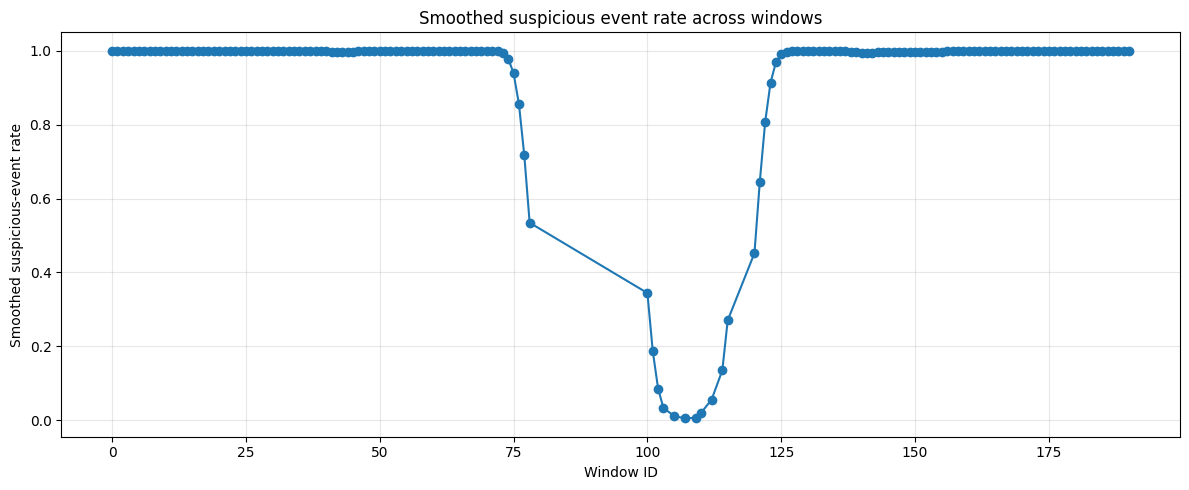

In [22]:
from scipy.ndimage import gaussian_filter1d

edge_diversity_smooth = gaussian_filter1d(window_summary["n_edges"].astype(float).to_numpy(), sigma=2)
event_rate_smooth = gaussian_filter1d(window_summary["suspicious_rate"].astype(float).to_numpy(), sigma=2)

plt.figure(figsize=(12, 5))
plt.plot(window_summary["window_id"], edge_diversity_smooth, marker="o")
plt.xlabel("Window ID")
plt.ylabel("Smoothed unique suspicious edges")
plt.title("Smoothed suspicious edge diversity across windows")
plt.grid(alpha=0.3)
plt.tight_layout()
smooth_edge_plot_path = save_figure("smoothed_suspicious_edge_diversity_across_windows.png")
print(f"Saved figure to: {smooth_edge_plot_path}")
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(window_summary["window_id"], event_rate_smooth, marker="o")
plt.xlabel("Window ID")
plt.ylabel("Smoothed suspicious-event rate")
plt.title("Smoothed suspicious event rate across windows")
plt.grid(alpha=0.3)
plt.tight_layout()
smooth_rate_plot_path = save_figure("smoothed_suspicious_event_rate_across_windows.png")
print(f"Saved figure to: {smooth_rate_plot_path}")
plt.show()

### Directed Graph Construction
Build one directed interaction graph per window and collect graph-level statistics.

In [23]:
window_graphs = {}
window_graph_stats = []

for wid, group in suspicious_df.groupby("window_id"):
    G = nx.DiGraph()

    edge_group = (
        group.groupby(["src_node", "dst_node"])
        .agg(
            edge_count=("event_id", "size"),
            mean_prob=("et_prob", "mean"),
            dominant_type=("type", lambda x: x.value_counts().index[0])
        )
        .reset_index()
    )

    for _, row in edge_group.iterrows():
        G.add_edge(
            row["src_node"],
            row["dst_node"],
            edge_count=int(row["edge_count"]),
            mean_prob=float(row["mean_prob"]),
            dominant_type=row["dominant_type"]
        )

    window_graphs[wid] = G

    window_graph_stats.append({
        "window_id": wid,
        "n_nodes": G.number_of_nodes(),
        "n_edges": G.number_of_edges(),
        "density": nx.density(G) if G.number_of_nodes() > 1 else 0.0
    })

graph_stats_df = pd.DataFrame(window_graph_stats)

print("Constructed window graphs:", len(window_graphs))
display(graph_stats_df.head(15))

Constructed window graphs: 161


,window_id,n_nodes,n_edges,density
0,0,4,5,0.416667
1,1,5,5,0.250000
2,2,3,2,0.333333
3,3,3,2,0.333333
4,4,3,2,0.333333
5,5,3,2,0.333333
6,6,3,2,0.333333
7,7,3,2,0.333333
8,8,3,2,0.333333
9,9,5,4,0.200000


### Sample Graph Inspection
Inspect a representative graph instance to verify the structure of nodes, edges, and attributes.

In [24]:
sample_wid = sorted(window_graphs.keys())[0]
G0 = window_graphs[sample_wid]

print("Sample window:", sample_wid)
print("Nodes:", G0.number_of_nodes())
print("Edges:", G0.number_of_edges())

sample_edges = list(G0.edges(data=True))[:10]
sample_edges


Sample window: 0
Nodes: 4
Edges: 5


[('192.168.1.193',
  '192.168.1.33',
  {'edge_count': 164,
   'mean_prob': 0.9983943089430896,
   'dominant_type': 'backdoor'}),
 ('192.168.1.193',
  '192.168.1.37',
  {'edge_count': 720,
   'mean_prob': 0.9999120370370369,
   'dominant_type': 'backdoor'}),
 ('192.168.1.33',
  '192.168.1.193',
  {'edge_count': 66, 'mean_prob': 1.0, 'dominant_type': 'backdoor'}),
 ('192.168.1.37',
  '121.0.0.42',
  {'edge_count': 2, 'mean_prob': 1.0, 'dominant_type': 'backdoor'}),
 ('192.168.1.37',
  '192.168.1.193',
  {'edge_count': 45, 'mean_prob': 1.0, 'dominant_type': 'backdoor'})]

### Node Activity Extraction
Compute node-level activity summaries from each window to support prediction tasks.

In [25]:
node_window_activity = []

for wid, group in suspicious_df.groupby("window_id"):
    active_nodes = set(group["src_node"]).union(set(group["dst_node"]))
    dominant_type = group["type"].value_counts().index[0]

    for node in active_nodes:
        node_window_activity.append({
            "window_id": wid,
            "node": node,
            "active_now": 1,
            "window_attack_type": dominant_type
        })

node_window_df = pd.DataFrame(node_window_activity)

print("Node-window activity shape:", node_window_df.shape)
display(node_window_df.head(20))

Node-window activity shape: (1680, 4)


,window_id,node,active_now,window_attack_type
0,0,192.168.1.193,1,backdoor
1,0,121.0.0.42,1,backdoor
2,0,192.168.1.37,1,backdoor
3,0,192.168.1.33,1,backdoor
4,1,192.168.1.193,1,backdoor
5,1,121.0.0.42,1,backdoor
6,1,192.168.1.37,1,backdoor
7,1,192.168.1.33,1,backdoor
8,1,103.38.120.36,1,backdoor
9,2,192.168.1.193,1,backdoor


### Valid Window Selection
Identify windows that can be used in next-step prediction by ensuring temporal continuity.

In [26]:
all_windows = sorted(suspicious_df["window_id"].unique())

all_nodes = sorted(set(suspicious_df["src_node"]).union(set(suspicious_df["dst_node"])))

full_grid = pd.MultiIndex.from_product(
    [all_windows, all_nodes],
    names=["window_id", "node"]
).to_frame(index=False)

activity_now = node_window_df[["window_id", "node", "active_now"]].drop_duplicates()

full_node_df = full_grid.merge(activity_now, on=["window_id", "node"], how="left")
full_node_df["active_now"] = full_node_df["active_now"].fillna(0).astype(int)

activity_next = activity_now.copy()
activity_next["window_id"] = activity_next["window_id"] - 1
activity_next = activity_next.rename(columns={"active_now": "active_next"})

full_node_df = full_node_df.merge(activity_next, on=["window_id", "node"], how="left")
full_node_df["active_next"] = full_node_df["active_next"].fillna(0).astype(int)

full_node_df = full_node_df.sort_values(["window_id", "node"]).reset_index(drop=True)

print("Full node prediction table shape:", full_node_df.shape)
display(full_node_df.head(20))

Full node prediction table shape: (39445, 4)


,window_id,node,active_now,active_next
0,0,101.119.11.11,0,0
1,0,101.119.11.17,0,0
2,0,101.119.11.209,0,0
3,0,101.119.11.8,0,0
4,0,103.126.53.123,0,0
5,0,103.15.158.128,0,0
6,0,103.15.158.129,0,0
7,0,103.214.220.220,0,0
8,0,103.231.98.196,0,0
9,0,103.243.221.109,0,0


### Temporal Range Check
Confirm the effective time horizon covered by the graph-based prediction dataset.

In [27]:
max_window = full_node_df["window_id"].max()

prediction_df = full_node_df[full_node_df["window_id"] < max_window].copy()

print("Prediction dataset shape:", prediction_df.shape)
print("\nTarget distribution:")
display(prediction_df["active_next"].value_counts(normalize=True))

Prediction dataset shape: (39200, 4)

Target distribution:


,proportion
active_next,
0,0.957883
1,0.042117


### Node-Level Graph Features
Extract structural features such as degree, PageRank, and betweenness for every active node.

In [28]:
feature_rows = []

for wid, G in window_graphs.items():
    indeg = dict(G.in_degree())
    outdeg = dict(G.out_degree())
    pagerank = nx.pagerank(G) if G.number_of_nodes() > 0 else {}
    betweenness = nx.betweenness_centrality(G) if G.number_of_nodes() > 1 else {}
    degree_centrality = nx.degree_centrality(G) if G.number_of_nodes() > 1 else {}

    edge_prob_sum_out = {}
    edge_count_sum_out = {}

    for u, v, data in G.edges(data=True):
        edge_prob_sum_out[u] = edge_prob_sum_out.get(u, 0.0) + data.get("mean_prob", 0.0)
        edge_count_sum_out[u] = edge_count_sum_out.get(u, 0) + data.get("edge_count", 0)

    nodes = set(G.nodes())

    for node in nodes:
        feature_rows.append({
            "window_id": wid,
            "node": node,
            "in_degree": indeg.get(node, 0),
            "out_degree": outdeg.get(node, 0),
            "pagerank": pagerank.get(node, 0.0),
            "betweenness": betweenness.get(node, 0.0),
            "degree_centrality": degree_centrality.get(node, 0.0),
            "edge_prob_sum_out": edge_prob_sum_out.get(node, 0.0),
            "edge_count_sum_out": edge_count_sum_out.get(node, 0)
        })

node_feature_df = pd.DataFrame(feature_rows)

print("Node feature table shape:", node_feature_df.shape)
display(node_feature_df.head(20))

Node feature table shape: (1680, 9)


,window_id,node,in_degree,out_degree,pagerank,betweenness,degree_centrality,edge_prob_sum_out,edge_count_sum_out
0,0,121.0.0.42,1,0,0.171884,0.000000,0.333333,0.000000,0
1,0,192.168.1.193,2,2,0.367602,0.500000,1.333333,1.998306,884
2,0,192.168.1.37,1,2,0.230257,0.333333,1.000000,2.000000,47
3,0,192.168.1.33,1,1,0.230257,0.000000,0.666667,1.000000,66
4,1,192.168.1.193,1,2,0.184332,0.166667,0.750000,2.000000,976
5,1,121.0.0.42,1,0,0.262673,0.000000,0.250000,0.000000,0
6,1,192.168.1.37,1,1,0.184332,0.166667,0.500000,1.000000,1
7,1,192.168.1.33,1,2,0.184332,0.083333,0.750000,2.000000,23
8,1,103.38.120.36,1,0,0.184332,0.000000,0.250000,0.000000,0
9,2,192.168.1.193,0,2,0.259741,0.000000,1.000000,2.000000,1000


### Prediction Table Assembly
Merge node-level graph features into the temporal prediction dataframe.

In [29]:
prediction_df = prediction_df.merge(
    node_feature_df,
    on=["window_id", "node"],
    how="left"
)

graph_feature_cols = [
    "in_degree", "out_degree", "pagerank", "betweenness",
    "degree_centrality", "edge_prob_sum_out", "edge_count_sum_out"
]

for col in graph_feature_cols:
    prediction_df[col] = prediction_df[col].fillna(0)

print("Merged prediction dataframe shape:", prediction_df.shape)
display(prediction_df.head(20))

Merged prediction dataframe shape: (39200, 11)


,window_id,node,active_now,active_next,in_degree,out_degree,pagerank,betweenness,degree_centrality,edge_prob_sum_out,edge_count_sum_out
0,0,101.119.11.11,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0,101.119.11.17,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0,101.119.11.209,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0,101.119.11.8,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0,103.126.53.123,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0,103.15.158.128,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,0,103.15.158.129,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,0,103.214.220.220,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,0,103.231.98.196,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,0,103.243.221.109,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Prediction Dataset Sanity Check
Review the number of windows and the overall size of the graph-prediction dataset.

In [30]:
print("Windows in prediction set:", prediction_df["window_id"].nunique())
print("Nodes in prediction set:", prediction_df["node"].nunique())

print("\nactive_now distribution:")
display(prediction_df["active_now"].value_counts(normalize=True))

print("\nactive_next distribution:")
display(prediction_df["active_next"].value_counts(normalize=True))

Windows in prediction set: 160
Nodes in prediction set: 245

active_now distribution:


,proportion
active_now,
0,0.957347
1,0.042653



active_next distribution:


,proportion
active_next,
0,0.957883
1,0.042117


### Save Graph-Stage Artifacts
Store the graph prediction dataset and graph summary tables in Google Drive.

In [31]:
graph_prediction_path = save_table(prediction_df, "ton_iot_graph_prediction_stage.csv", index=False)
window_summary_path = save_table(window_summary, "ton_iot_window_summary.csv", index=False)
graph_stats_path = save_table(graph_stats_df, "ton_iot_window_graph_stats.csv", index=False)

print("Saved graph-stage artifacts to Google Drive.")
print(graph_prediction_path)
print(window_summary_path)
print(graph_stats_path)


[Saved table] /content/drive/MyDrive/Outputs/Amal/MBZUAI-3/tables/ton_iot_graph_prediction_stage.csv
[Saved table] /content/drive/MyDrive/Outputs/Amal/MBZUAI-3/tables/ton_iot_window_summary.csv
[Saved table] /content/drive/MyDrive/Outputs/Amal/MBZUAI-3/tables/ton_iot_window_graph_stats.csv
Saved graph-stage artifacts to Google Drive.
/content/drive/MyDrive/Outputs/Amal/MBZUAI-3/tables/ton_iot_graph_prediction_stage.csv
/content/drive/MyDrive/Outputs/Amal/MBZUAI-3/tables/ton_iot_window_summary.csv
/content/drive/MyDrive/Outputs/Amal/MBZUAI-3/tables/ton_iot_window_graph_stats.csv


## Stage 3 — Source Transition Modeling
The following cells reformulate the problem at the source-node level and model how suspicious sources evolve across windows.

### Source Transition Objective
For each source node and window, the notebook estimates future activity, interaction diversity, and transition behavior in the next window.

This source-transition stage creates the intermediate dataset later reused for next-target prediction.

### Source-Window Aggregation
Aggregate suspicious activity at the source-node level within each window.

In [32]:
source_window_df = (
    suspicious_df.groupby(["window_id", "src_node"])
    .agg(
        n_events=("event_id", "size"),
        n_unique_targets=("dst_node", "nunique"),
        mean_prob=("et_prob", "mean"),
        max_prob=("et_prob", "max"),
        dominant_type=("type", lambda x: x.value_counts().index[0]),
        dominant_target=("dst_node", lambda x: x.value_counts().index[0])
    )
    .reset_index()
)

print("Source-window summary shape:", source_window_df.shape)
display(source_window_df.head(20))

Source-window summary shape: (369, 8)


,window_id,src_node,n_events,n_unique_targets,mean_prob,max_prob,dominant_type,dominant_target
0,0,192.168.1.193,884,2,0.99963,1.0,backdoor,192.168.1.37
1,0,192.168.1.33,66,1,1.00000,1.0,backdoor,192.168.1.193
2,0,192.168.1.37,47,2,1.00000,1.0,backdoor,192.168.1.193
3,1,192.168.1.193,976,2,1.00000,1.0,backdoor,192.168.1.37
4,1,192.168.1.33,23,2,1.00000,1.0,backdoor,192.168.1.193
5,1,192.168.1.37,1,1,1.00000,1.0,backdoor,121.0.0.42
6,2,192.168.1.193,1000,2,1.00000,1.0,backdoor,192.168.1.33
7,3,192.168.1.193,1000,2,1.00000,1.0,backdoor,192.168.1.33
8,4,192.168.1.193,1000,2,1.00000,1.0,backdoor,192.168.1.33
9,5,192.168.1.193,1000,2,1.00000,1.0,backdoor,192.168.1.33


### Target Concentration Feature
Add a concentration measure that captures how focused each source node is on its destinations.

In [33]:
def compute_target_concentration(group):
    vc = group["dst_node"].value_counts(normalize=True)
    return vc.iloc[0] if len(vc) > 0 else 0.0

target_conc = (
    suspicious_df.groupby(["window_id", "src_node"])
    .apply(compute_target_concentration)
    .reset_index(name="target_concentration")
)

source_window_df = source_window_df.merge(
    target_conc,
    on=["window_id", "src_node"],
    how="left"
)

print("Updated source-window summary:")
display(source_window_df.head(20))

Updated source-window summary:


,window_id,src_node,n_events,n_unique_targets,mean_prob,max_prob,dominant_type,dominant_target,target_concentration
0,0,192.168.1.193,884,2,0.99963,1.0,backdoor,192.168.1.37,0.814480
1,0,192.168.1.33,66,1,1.00000,1.0,backdoor,192.168.1.193,1.000000
2,0,192.168.1.37,47,2,1.00000,1.0,backdoor,192.168.1.193,0.957447
3,1,192.168.1.193,976,2,1.00000,1.0,backdoor,192.168.1.37,0.861680
4,1,192.168.1.33,23,2,1.00000,1.0,backdoor,192.168.1.193,0.956522
5,1,192.168.1.37,1,1,1.00000,1.0,backdoor,121.0.0.42,1.000000
6,2,192.168.1.193,1000,2,1.00000,1.0,backdoor,192.168.1.33,0.536000
7,3,192.168.1.193,1000,2,1.00000,1.0,backdoor,192.168.1.33,0.538000
8,4,192.168.1.193,1000,2,1.00000,1.0,backdoor,192.168.1.33,0.530000
9,5,192.168.1.193,1000,2,1.00000,1.0,backdoor,192.168.1.33,0.537000


### Source-Side Graph Features
Merge graph-centrality descriptors into the source-window dataset.

In [34]:
source_graph_features = []

for wid, G in window_graphs.items():
    outdeg = dict(G.out_degree())
    indeg = dict(G.in_degree())
    pagerank = nx.pagerank(G) if G.number_of_nodes() > 0 else {}
    betweenness = nx.betweenness_centrality(G) if G.number_of_nodes() > 1 else {}

    for node in G.nodes():
        source_graph_features.append({
            "window_id": wid,
            "src_node": node,
            "src_out_degree": outdeg.get(node, 0),
            "src_in_degree": indeg.get(node, 0),
            "src_pagerank": pagerank.get(node, 0.0),
            "src_betweenness": betweenness.get(node, 0.0)
        })

source_graph_df = pd.DataFrame(source_graph_features)

source_window_df = source_window_df.merge(
    source_graph_df,
    on=["window_id", "src_node"],
    how="left"
)

print("Source-window table with graph features:", source_window_df.shape)
display(source_window_df.head(20))

Source-window table with graph features: (369, 13)


,window_id,src_node,n_events,n_unique_targets,mean_prob,max_prob,dominant_type,dominant_target,target_concentration,src_out_degree,src_in_degree,src_pagerank,src_betweenness
0,0,192.168.1.193,884,2,0.99963,1.0,backdoor,192.168.1.37,0.814480,2,2,0.367602,0.500000
1,0,192.168.1.33,66,1,1.00000,1.0,backdoor,192.168.1.193,1.000000,1,1,0.230257,0.000000
2,0,192.168.1.37,47,2,1.00000,1.0,backdoor,192.168.1.193,0.957447,2,1,0.230257,0.333333
3,1,192.168.1.193,976,2,1.00000,1.0,backdoor,192.168.1.37,0.861680,2,1,0.184332,0.166667
4,1,192.168.1.33,23,2,1.00000,1.0,backdoor,192.168.1.193,0.956522,2,1,0.184332,0.083333
5,1,192.168.1.37,1,1,1.00000,1.0,backdoor,121.0.0.42,1.000000,1,1,0.184332,0.166667
6,2,192.168.1.193,1000,2,1.00000,1.0,backdoor,192.168.1.33,0.536000,2,0,0.259741,0.000000
7,3,192.168.1.193,1000,2,1.00000,1.0,backdoor,192.168.1.33,0.538000,2,0,0.259741,0.000000
8,4,192.168.1.193,1000,2,1.00000,1.0,backdoor,192.168.1.33,0.530000,2,0,0.259741,0.000000
9,5,192.168.1.193,1000,2,1.00000,1.0,backdoor,192.168.1.33,0.537000,2,0,0.259741,0.000000


### Next-Window Target Construction
Create next-window targets so each source can be modeled as a temporal transition problem.

In [35]:
next_df = source_window_df[[
    "window_id", "src_node", "n_unique_targets", "mean_prob", "n_events"
]].copy()

next_df["window_id"] = next_df["window_id"] - 1
next_df = next_df.rename(columns={
    "n_unique_targets": "next_n_unique_targets",
    "mean_prob": "next_mean_prob",
    "n_events": "next_n_events"
})

model_df = source_window_df.merge(
    next_df,
    on=["window_id", "src_node"],
    how="left"
)

model_df["active_next_src"] = (~model_df["next_n_events"].isna()).astype(int)
model_df["next_n_unique_targets"] = model_df["next_n_unique_targets"].fillna(0)
model_df["next_mean_prob"] = model_df["next_mean_prob"].fillna(0)
model_df["next_n_events"] = model_df["next_n_events"].fillna(0)

print("Source transition modeling table shape:", model_df.shape)
display(model_df.head(20))

Source transition modeling table shape: (369, 17)


,window_id,src_node,n_events,n_unique_targets,mean_prob,max_prob,dominant_type,dominant_target,target_concentration,src_out_degree,src_in_degree,src_pagerank,src_betweenness,next_n_unique_targets,next_mean_prob,next_n_events,active_next_src
0,0,192.168.1.193,884,2,0.99963,1.0,backdoor,192.168.1.37,0.814480,2,2,0.367602,0.500000,2.0,1.0,976.0,1
1,0,192.168.1.33,66,1,1.00000,1.0,backdoor,192.168.1.193,1.000000,1,1,0.230257,0.000000,2.0,1.0,23.0,1
2,0,192.168.1.37,47,2,1.00000,1.0,backdoor,192.168.1.193,0.957447,2,1,0.230257,0.333333,1.0,1.0,1.0,1
3,1,192.168.1.193,976,2,1.00000,1.0,backdoor,192.168.1.37,0.861680,2,1,0.184332,0.166667,2.0,1.0,1000.0,1
4,1,192.168.1.33,23,2,1.00000,1.0,backdoor,192.168.1.193,0.956522,2,1,0.184332,0.083333,0.0,0.0,0.0,0
5,1,192.168.1.37,1,1,1.00000,1.0,backdoor,121.0.0.42,1.000000,1,1,0.184332,0.166667,0.0,0.0,0.0,0
6,2,192.168.1.193,1000,2,1.00000,1.0,backdoor,192.168.1.33,0.536000,2,0,0.259741,0.000000,2.0,1.0,1000.0,1
7,3,192.168.1.193,1000,2,1.00000,1.0,backdoor,192.168.1.33,0.538000,2,0,0.259741,0.000000,2.0,1.0,1000.0,1
8,4,192.168.1.193,1000,2,1.00000,1.0,backdoor,192.168.1.33,0.530000,2,0,0.259741,0.000000,2.0,1.0,1000.0,1
9,5,192.168.1.193,1000,2,1.00000,1.0,backdoor,192.168.1.33,0.537000,2,0,0.259741,0.000000,2.0,1.0,1000.0,1


### Temporal Cutoff Definition
Determine chronological split points for training, validation, and testing.

In [36]:
max_window = model_df["window_id"].max()
model_df = model_df[model_df["window_id"] < max_window].copy()

print("Filtered modeling table shape:", model_df.shape)

print("\nTarget: active_next_src")
display(model_df["active_next_src"].value_counts(normalize=True))

print("\nTarget: next_n_unique_targets summary")
display(model_df["next_n_unique_targets"].describe())

Filtered modeling table shape: (368, 17)

Target: active_next_src


,proportion
active_next_src,
1,0.877717
0,0.122283



Target: next_n_unique_targets summary


,next_n_unique_targets
count,368.000000
mean,5.711957
std,7.083670
min,0.000000
25%,1.000000
50%,5.000000
75%,8.000000
max,75.000000


### Source Persistence Features
Measure whether a source remains active over time and merge persistence-oriented descriptors.

In [37]:
source_persistence = (
    model_df.groupby("src_node")
    .agg(
        n_windows=("window_id", "size"),
        active_next_rate=("active_next_src", "mean"),
        avg_targets_now=("n_unique_targets", "mean"),
        avg_targets_next=("next_n_unique_targets", "mean")
    )
    .sort_values("n_windows", ascending=False)
)

display(source_persistence.head(30))

,n_windows,active_next_rate,avg_targets_now,avg_targets_next
src_node,,,,
192.168.1.30,98,0.948980,8.540816,8.163265
192.168.1.31,91,0.945055,6.351648,6.098901
192.168.1.193,35,0.942857,1.942857,1.857143
192.168.1.32,35,1.000000,9.971429,9.942857
192.168.1.37,20,0.800000,1.100000,0.800000
192.168.1.39,20,0.950000,8.250000,7.850000
192.168.1.33,20,0.800000,1.100000,0.850000
192.168.1.36,15,0.933333,4.266667,3.866667
192.168.1.180,8,0.125000,1.500000,0.125000


### Final Source Transition Table
Inspect the completed source-transition modeling table before learning.

In [38]:
model_df["dominant_type"] = model_df["dominant_type"].astype(str)

display(model_df["dominant_type"].value_counts())

,count
dominant_type,
scanning,62
dos,58
ransomware,48
password,41
ddos,39
injection,38
xss,30
backdoor,27
normal,17


### Source Transition Modeling Setup
Define the final feature set, prediction targets, and chronological train-validation-test partitions.

In [39]:
feature_cols = [
    "n_events",
    "n_unique_targets",
    "mean_prob",
    "max_prob",
    "target_concentration",
    "src_out_degree",
    "src_in_degree",
    "src_pagerank",
    "src_betweenness",
    "dominant_type"
]

target_col_cls = "active_next_src"
target_col_reg = "next_n_unique_targets"

model_df = model_df.sort_values(["window_id", "src_node"]).reset_index(drop=True)

split_window_1 = int(model_df["window_id"].max() * 0.70)
split_window_2 = int(model_df["window_id"].max() * 0.85)

train_df = model_df[model_df["window_id"] <= split_window_1].copy()
val_df = model_df[(model_df["window_id"] > split_window_1) & (model_df["window_id"] <= split_window_2)].copy()
test_df = model_df[model_df["window_id"] > split_window_2].copy()

print("Train shape:", train_df.shape)
print("Val shape:", val_df.shape)
print("Test shape:", test_df.shape)

print("\nTrain target distribution:")
display(train_df[target_col_cls].value_counts(normalize=True))

print("\nVal target distribution:")
display(val_df[target_col_cls].value_counts(normalize=True))

print("\nTest target distribution:")
display(test_df[target_col_cls].value_counts(normalize=True))

Train shape: (212, 17)
Val shape: (82, 17)
Test shape: (74, 17)

Train target distribution:


,proportion
active_next_src,
1,0.825472
0,0.174528



Val target distribution:


,proportion
active_next_src,
1,0.939024
0,0.060976



Test target distribution:


,proportion
active_next_src,
1,0.959459
0,0.040541


### Source Model Preprocessing
Create preprocessing logic for the source-transition classification and regression models.

In [40]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

categorical_feature_cols = ["dominant_type"]
numeric_feature_cols = [c for c in feature_cols if c not in categorical_feature_cols]

preprocessor_source = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median"))
        ]), numeric_feature_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), categorical_feature_cols)
    ]
)

print("Source-transition preprocessor ready.")

Source-transition preprocessor ready.


### Source Activity Classification
Train and evaluate the classifier that predicts whether a source stays active in the next window.

In [41]:
clf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor_source),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced"
    ))
])

clf_pipeline.fit(train_df[feature_cols], train_df[target_col_cls])

val_probs = clf_pipeline.predict_proba(val_df[feature_cols])[:, 1]
val_preds = (val_probs >= 0.5).astype(int)

from sklearn.metrics import roc_auc_score, average_precision_score, classification_report, confusion_matrix, accuracy_score, f1_score, precision_score, recall_score, balanced_accuracy_score

val_cls_metrics = {
    "accuracy": accuracy_score(val_df[target_col_cls], val_preds),
    "balanced_accuracy": balanced_accuracy_score(val_df[target_col_cls], val_preds),
    "precision": precision_score(val_df[target_col_cls], val_preds, zero_division=0),
    "recall": recall_score(val_df[target_col_cls], val_preds, zero_division=0),
    "f1": f1_score(val_df[target_col_cls], val_preds, zero_division=0),
    "roc_auc": roc_auc_score(val_df[target_col_cls], val_probs),
    "avg_precision": average_precision_score(val_df[target_col_cls], val_probs)
}

print("Validation classification metrics:")
for k, v in val_cls_metrics.items():
    print(f"{k}: {v:.6f}")

print("\nClassification report:")
print(classification_report(val_df[target_col_cls], val_preds, digits=4))

print("\nConfusion matrix:")
print(confusion_matrix(val_df[target_col_cls], val_preds))

Validation classification metrics:
accuracy: 0.914634
balanced_accuracy: 0.487013
precision: 0.937500
recall: 0.974026
f1: 0.955414
roc_auc: 0.687013
avg_precision: 0.971459

Classification report:
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000         5
           1     0.9375    0.9740    0.9554        77

    accuracy                         0.9146        82
   macro avg     0.4688    0.4870    0.4777        82
weighted avg     0.8803    0.9146    0.8972        82


Confusion matrix:
[[ 0  5]
 [ 2 75]]


### Source Expansion Regression
Train the regression model that estimates the future reach of an active source.

In [42]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

reg_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor_source),
    ("regressor", RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ))
])

reg_pipeline.fit(train_df[feature_cols], train_df[target_col_reg])

val_reg_preds = reg_pipeline.predict(val_df[feature_cols])

val_mse = mean_squared_error(val_df[target_col_reg], val_reg_preds)
val_rmse = np.sqrt(val_mse)

val_reg_metrics = {
    "mae": mean_absolute_error(val_df[target_col_reg], val_reg_preds),
    "rmse": val_rmse,
    "r2": r2_score(val_df[target_col_reg], val_reg_preds)
}

print("Validation regression metrics:")
for k, v in val_reg_metrics.items():
    print(f"{k}: {v:.6f}")

Validation regression metrics:
mae: 2.633821
rmse: 3.168051
r2: 0.404893


### Regression Test Evaluation
Evaluate the regression model on the held-out temporal test set.

In [43]:
test_reg_preds = reg_pipeline.predict(test_df[feature_cols])

test_mse = mean_squared_error(test_df[target_col_reg], test_reg_preds)
test_rmse = np.sqrt(test_mse)

test_reg_metrics = {
    "mae": mean_absolute_error(test_df[target_col_reg], test_reg_preds),
    "rmse": test_rmse,
    "r2": r2_score(test_df[target_col_reg], test_reg_preds)
}

print("\nTest regression metrics:")
for k, v in test_reg_metrics.items():
    print(f"{k}: {v:.6f}")


Test regression metrics:
mae: 3.032087
rmse: 3.619243
r2: 0.083737


### Save Source Transition Dataset
Export the source-transition dataset to Google Drive for the downstream target-prediction stage.

In [44]:
source_transition_path = save_table(model_df, "ton_iot_source_transition_stage.csv", index=False)
print("Saved source-transition dataset to Google Drive.")
print(source_transition_path)

[Saved table] /content/drive/MyDrive/Outputs/Amal/MBZUAI-3/tables/ton_iot_source_transition_stage.csv
Saved source-transition dataset to Google Drive.
/content/drive/MyDrive/Outputs/Amal/MBZUAI-3/tables/ton_iot_source_transition_stage.csv


## Stage 4 — Next-Target Bucket Prediction
This section predicts the type of destination a suspicious source is most likely to target next.

### Revised Predictive Target
Each source-window pair is labeled according to whether the next dominant destination disappears, reuses a known target, moves to a new private/internal target, or shifts elsewhere depending on the notebook's bucket logic.

The next cells engineer interpretable target buckets and evaluate a dedicated classifier for this task.

### Reload Transition Dataset
Load the saved transition dataset from Google Drive to start the next-target prediction stage.

In [45]:
model_df = pd.read_csv(TABLE_DIR / "ton_iot_source_transition_stage.csv")
print("Loaded source-transition dataset:", model_df.shape)
display(model_df.head())

Loaded source-transition dataset: (368, 17)


,window_id,src_node,n_events,n_unique_targets,mean_prob,max_prob,dominant_type,dominant_target,target_concentration,src_out_degree,src_in_degree,src_pagerank,src_betweenness,next_n_unique_targets,next_mean_prob,next_n_events,active_next_src
0,0,192.168.1.193,884,2,0.99963,1.0,backdoor,192.168.1.37,0.814480,2,2,0.367602,0.500000,2.0,1.0,976.0,1
1,0,192.168.1.33,66,1,1.00000,1.0,backdoor,192.168.1.193,1.000000,1,1,0.230257,0.000000,2.0,1.0,23.0,1
2,0,192.168.1.37,47,2,1.00000,1.0,backdoor,192.168.1.193,0.957447,2,1,0.230257,0.333333,1.0,1.0,1.0,1
3,1,192.168.1.193,976,2,1.00000,1.0,backdoor,192.168.1.37,0.861680,2,1,0.184332,0.166667,2.0,1.0,1000.0,1
4,1,192.168.1.33,23,2,1.00000,1.0,backdoor,192.168.1.193,0.956522,2,1,0.184332,0.083333,0.0,0.0,0.0,0


### Next-Target Label Creation
Define the next dominant destination for each source node and create the target-analysis table.

In [46]:
source_next_target = source_window_df[["window_id", "src_node", "dominant_target"]].copy()
source_next_target["window_id"] = source_next_target["window_id"] - 1
source_next_target = source_next_target.rename(columns={
    "dominant_target": "next_dominant_target"
})

model_target_df = source_window_df.merge(
    source_next_target,
    on=["window_id", "src_node"],
    how="left"
)

max_window = model_target_df["window_id"].max()
model_target_df = model_target_df[model_target_df["window_id"] < max_window].copy()

print("Target dataframe shape:", model_target_df.shape)
display(model_target_df.head(20))

Target dataframe shape: (368, 14)


,window_id,src_node,n_events,n_unique_targets,mean_prob,max_prob,dominant_type,dominant_target,target_concentration,src_out_degree,src_in_degree,src_pagerank,src_betweenness,next_dominant_target
0,0,192.168.1.193,884,2,0.99963,1.0,backdoor,192.168.1.37,0.814480,2,2,0.367602,0.500000,192.168.1.37
1,0,192.168.1.33,66,1,1.00000,1.0,backdoor,192.168.1.193,1.000000,1,1,0.230257,0.000000,192.168.1.193
2,0,192.168.1.37,47,2,1.00000,1.0,backdoor,192.168.1.193,0.957447,2,1,0.230257,0.333333,121.0.0.42
3,1,192.168.1.193,976,2,1.00000,1.0,backdoor,192.168.1.37,0.861680,2,1,0.184332,0.166667,192.168.1.33
4,1,192.168.1.33,23,2,1.00000,1.0,backdoor,192.168.1.193,0.956522,2,1,0.184332,0.083333,NaN
5,1,192.168.1.37,1,1,1.00000,1.0,backdoor,121.0.0.42,1.000000,1,1,0.184332,0.166667,NaN
6,2,192.168.1.193,1000,2,1.00000,1.0,backdoor,192.168.1.33,0.536000,2,0,0.259741,0.000000,192.168.1.33
7,3,192.168.1.193,1000,2,1.00000,1.0,backdoor,192.168.1.33,0.538000,2,0,0.259741,0.000000,192.168.1.33
8,4,192.168.1.193,1000,2,1.00000,1.0,backdoor,192.168.1.33,0.530000,2,0,0.259741,0.000000,192.168.1.33
9,5,192.168.1.193,1000,2,1.00000,1.0,backdoor,192.168.1.33,0.537000,2,0,0.259741,0.000000,192.168.1.33


### IP Bucket Helper Utilities
Build helper logic for categorizing targets into interpretable destination buckets.

In [47]:
import ipaddress

def is_private_ip(ip_str):
    try:
        return ipaddress.ip_address(str(ip_str)).is_private
    except:
        return False

### Target Table Ordering
Sort, clean, and standardize the target-prediction dataset before training.

In [48]:
model_target_df = model_target_df.sort_values(["src_node", "window_id"]).reset_index(drop=True)

history_seen_targets = {}
risk_buckets = []

for _, row in model_target_df.iterrows():
    src = row["src_node"]
    current_target = row["dominant_target"]
    next_target = row["next_dominant_target"]

    if src not in history_seen_targets:
        history_seen_targets[src] = set()

    seen_before = history_seen_targets[src]

    if pd.isna(next_target):
        bucket = 0   # disappears next window
    elif next_target in seen_before or next_target == current_target:
        bucket = 1   # continues to same / seen target
    elif is_private_ip(next_target):
        bucket = 2   # new internal/private target
    else:
        bucket = 3   # new external/public target

    risk_buckets.append(bucket)

    history_seen_targets[src].add(current_target)

model_target_df["next_target_bucket"] = risk_buckets

print("Bucket distribution:")
display(model_target_df["next_target_bucket"].value_counts(normalize=True).sort_index())
display(model_target_df["next_target_bucket"].value_counts().sort_index())

Bucket distribution:


,proportion
next_target_bucket,
0,0.122283
1,0.782609
2,0.065217
3,0.029891


,count
next_target_bucket,
0,45
1,288
2,24
3,11


### Bucket Feature Engineering
Merge the required fields and finalize the variables needed for bucket prediction.

In [49]:
feature_merge_cols = [
    "window_id", "src_node", "n_events", "n_unique_targets", "mean_prob", "max_prob",
    "dominant_type", "target_concentration",
    "src_out_degree", "src_in_degree", "src_pagerank", "src_betweenness"
]

model_target_df = model_target_df.merge(
    model_df[feature_merge_cols].drop_duplicates(),
    on=["window_id", "src_node", "n_events", "n_unique_targets", "mean_prob", "max_prob",
        "dominant_type", "target_concentration",
        "src_out_degree", "src_in_degree", "src_pagerank", "src_betweenness"],
    how="left"
)

print("Merged target dataset shape:", model_target_df.shape)
display(model_target_df.head(10))

Merged target dataset shape: (368, 15)


,window_id,src_node,n_events,n_unique_targets,mean_prob,max_prob,dominant_type,dominant_target,target_concentration,src_out_degree,src_in_degree,src_pagerank,src_betweenness,next_dominant_target,next_target_bucket
0,78,192.168.1.1,2,1,1.000000,1.000000,mitm,192.168.1.31,1.00,1,2,0.010267,0.001151,NaN,0
1,102,192.168.1.1,1,1,0.938628,0.938628,normal,192.168.1.195,1.00,1,0,0.155703,0.000000,NaN,0
2,107,192.168.1.1,1,1,1.000000,1.000000,normal,192.168.1.195,1.00,1,0,0.350877,0.000000,NaN,0
3,77,192.168.1.152,1,1,1.000000,1.000000,mitm,192.168.1.34,1.00,1,3,0.016942,0.013462,192.168.1.31,2
4,78,192.168.1.152,1,1,1.000000,1.000000,mitm,192.168.1.31,1.00,1,1,0.010157,0.000000,NaN,0
5,109,192.168.1.152,1,1,0.903333,0.903333,normal,192.168.1.195,1.00,1,0,0.350877,0.000000,NaN,0
6,77,192.168.1.169,1,1,1.000000,1.000000,mitm,192.168.1.34,1.00,1,1,0.014728,0.000000,NaN,0
7,100,192.168.1.180,1,1,0.953333,0.953333,normal,103.126.53.123,1.00,1,0,0.350877,0.000000,NaN,0
8,103,192.168.1.180,4,4,0.972500,1.000000,normal,172.217.167.77,0.25,4,0,0.085247,0.000000,NaN,0
9,105,192.168.1.180,2,2,0.980000,1.000000,normal,216.58.200.99,0.50,2,0,0.259741,0.000000,NaN,0


### Bucket Prediction Setup
Define features, target labels, and chronological splits for the next-target bucket classifier.

In [50]:
feature_cols_bucket = [
    "n_events",
    "n_unique_targets",
    "mean_prob",
    "max_prob",
    "target_concentration",
    "src_out_degree",
    "src_in_degree",
    "src_pagerank",
    "src_betweenness",
    "dominant_type"
]

target_bucket_col = "next_target_bucket"

model_target_df = model_target_df.sort_values(["window_id", "src_node"]).reset_index(drop=True)

split_window_1 = int(model_target_df["window_id"].max() * 0.70)
split_window_2 = int(model_target_df["window_id"].max() * 0.85)

train_bucket_df = model_target_df[model_target_df["window_id"] <= split_window_1].copy()
val_bucket_df = model_target_df[(model_target_df["window_id"] > split_window_1) & (model_target_df["window_id"] <= split_window_2)].copy()
test_bucket_df = model_target_df[model_target_df["window_id"] > split_window_2].copy()

print("Train shape:", train_bucket_df.shape)
print("Val shape:", val_bucket_df.shape)
print("Test shape:", test_bucket_df.shape)

print("\nTrain bucket distribution:")
display(train_bucket_df[target_bucket_col].value_counts(normalize=True).sort_index())

print("\nVal bucket distribution:")
display(val_bucket_df[target_bucket_col].value_counts(normalize=True).sort_index())

print("\nTest bucket distribution:")
display(test_bucket_df[target_bucket_col].value_counts(normalize=True).sort_index())

Train shape: (212, 15)
Val shape: (82, 15)
Test shape: (74, 15)

Train bucket distribution:


,proportion
next_target_bucket,
0,0.174528
1,0.721698
2,0.066038
3,0.037736



Val bucket distribution:


,proportion
next_target_bucket,
0,0.060976
1,0.890244
2,0.048780



Test bucket distribution:


,proportion
next_target_bucket,
0,0.040541
1,0.837838
2,0.081081
3,0.040541


### Bucket Classifier Preprocessing
Construct the preprocessing and modeling pipeline for destination-bucket prediction.

In [51]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, balanced_accuracy_score, f1_score

categorical_bucket_cols = ["dominant_type"]
numeric_bucket_cols = [c for c in feature_cols_bucket if c not in categorical_bucket_cols]

preprocessor_bucket = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median"))
        ]), numeric_bucket_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), categorical_bucket_cols)
    ]
)

bucket_clf = Pipeline(steps=[
    ("preprocessor", preprocessor_bucket),
    ("classifier", RandomForestClassifier(
        n_estimators=400,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced"
    ))
])

bucket_clf.fit(train_bucket_df[feature_cols_bucket], train_bucket_df[target_bucket_col])

print("Bucket classifier trained.")

Bucket classifier trained.


### Bucket Validation Results
Evaluate next-target bucket prediction performance on the validation windows.

In [52]:
val_bucket_pred = bucket_clf.predict(val_bucket_df[feature_cols_bucket])

print("Validation accuracy:", accuracy_score(val_bucket_df[target_bucket_col], val_bucket_pred))
print("Validation balanced accuracy:", balanced_accuracy_score(val_bucket_df[target_bucket_col], val_bucket_pred))
print("Validation macro F1:", f1_score(val_bucket_df[target_bucket_col], val_bucket_pred, average="macro"))
print("Validation weighted F1:", f1_score(val_bucket_df[target_bucket_col], val_bucket_pred, average="weighted"))

print("\nValidation classification report:")
print(classification_report(val_bucket_df[target_bucket_col], val_bucket_pred, digits=4))

print("\nValidation confusion matrix:")
print(confusion_matrix(val_bucket_df[target_bucket_col], val_bucket_pred))

Validation accuracy: 0.8658536585365854
Validation balanced accuracy: 0.3242009132420091
Validation macro F1: 0.3093681917211329
Validation weighted F1: 0.826239438864977

Validation classification report:
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000         5
           1     0.8875    0.9726    0.9281        73
           2     0.0000    0.0000    0.0000         4

    accuracy                         0.8659        82
   macro avg     0.2958    0.3242    0.3094        82
weighted avg     0.7901    0.8659    0.8262        82


Validation confusion matrix:
[[ 0  5  0]
 [ 2 71  0]
 [ 0  4  0]]


### Bucket Test Results
Measure next-target bucket prediction performance on the held-out test windows.

In [53]:
test_bucket_pred = bucket_clf.predict(test_bucket_df[feature_cols_bucket])

print("Test accuracy:", accuracy_score(test_bucket_df[target_bucket_col], test_bucket_pred))
print("Test balanced accuracy:", balanced_accuracy_score(test_bucket_df[target_bucket_col], test_bucket_pred))
print("Test macro F1:", f1_score(test_bucket_df[target_bucket_col], test_bucket_pred, average="macro"))
print("Test weighted F1:", f1_score(test_bucket_df[target_bucket_col], test_bucket_pred, average="weighted"))

print("\nTest classification report:")
print(classification_report(test_bucket_df[target_bucket_col], test_bucket_pred, digits=4))

print("\nTest confusion matrix:")
print(confusion_matrix(test_bucket_df[target_bucket_col], test_bucket_pred))

Test accuracy: 0.7972972972972973
Test balanced accuracy: 0.23790322580645162
Test macro F1: 0.22348484848484848
Test weighted F1: 0.7489762489762489

Test classification report:
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000         3
           1     0.8429    0.9516    0.8939        62
           2     0.0000    0.0000    0.0000         6
           3     0.0000    0.0000    0.0000         3

    accuracy                         0.7973        74
   macro avg     0.2107    0.2379    0.2235        74
weighted avg     0.7062    0.7973    0.7490        74


Test confusion matrix:
[[ 0  3  0  0]
 [ 3 59  0  0]
 [ 1  5  0  0]
 [ 0  3  0  0]]


### Feature Importance Review
Inspect the most influential predictors used by the destination-bucket classifier.

In [54]:
rf_model = bucket_clf.named_steps["classifier"]
ohe = bucket_clf.named_steps["preprocessor"]

cat_feature_names = list(
    ohe.named_transformers_["cat"]
       .named_steps["onehot"]
       .get_feature_names_out(categorical_bucket_cols)
)

all_feature_names = numeric_bucket_cols + cat_feature_names

importances = pd.DataFrame({
    "feature": all_feature_names,
    "importance": rf_model.feature_importances_
}).sort_values("importance", ascending=False)

display(importances.head(20))

,feature,importance
0,n_events,0.260527
4,target_concentration,0.164071
7,src_pagerank,0.140737
2,mean_prob,0.110609
5,src_out_degree,0.078966
1,n_unique_targets,0.072648
6,src_in_degree,0.030740
8,src_betweenness,0.030075
11,dominant_type_dos,0.022931
14,dominant_type_normal,0.020230


### Save Target-Bucket Dataset
Write the next-target bucket dataset to Google Drive.

In [55]:
target_bucket_path = save_table(model_target_df, "ton_iot_next_target_bucket_stage.csv", index=False)
print("Saved next-target bucket dataset to Google Drive.")
print(target_bucket_path)

[Saved table] /content/drive/MyDrive/Outputs/Amal/MBZUAI-3/tables/ton_iot_next_target_bucket_stage.csv
Saved next-target bucket dataset to Google Drive.
/content/drive/MyDrive/Outputs/Amal/MBZUAI-3/tables/ton_iot_next_target_bucket_stage.csv


## Stage 5 — Node-Risk Ranking
The final section frames the problem as ranking candidate nodes by their likelihood of appearing in the next suspicious window.

### Ranking Objective
Input: the graph at time *t*. Output: a risk score for every candidate node. Ground truth: nodes that truly appear in suspicious interactions at time *t + 1*.

The notebook compares structural baselines with classical diffusion and a quantum-inspired diffusion mechanism.

### Dynamic Ground-Truth Construction for Ranking
Build a **non-trivial** next-window ranking target. Instead of treating every active next-window node as equally correct, the notebook identifies the nodes whose suspicious risk increases the most from window *t* to window *t+1*. This yields a smaller and more informative ground-truth set for predictive ranking.


In [56]:
def compute_window_node_risk(group):
    src_strength = group.groupby("src_node")["et_prob"].sum()
    dst_strength = group.groupby("dst_node")["et_prob"].sum() * 0.75
    src_diversity = group.groupby("src_node")["dst_node"].nunique()
    dst_diversity = group.groupby("dst_node")["src_node"].nunique()

    nodes = sorted(set(src_strength.index).union(dst_strength.index))
    risk = {}
    for node in nodes:
        risk[node] = (
            float(src_strength.get(node, 0.0))
            + float(dst_strength.get(node, 0.0))
            + 0.25 * float(src_diversity.get(node, 0))
            + 0.15 * float(dst_diversity.get(node, 0))
        )
    return risk

window_active_nodes = {}
window_node_risk_scores = {}
window_true_risk_nodes = {}

for wid, group in suspicious_df.groupby("window_id"):
    active_nodes = set(group["src_node"]).union(set(group["dst_node"]))
    window_active_nodes[wid] = active_nodes
    window_node_risk_scores[wid] = compute_window_node_risk(group)

valid_windows = sorted(window_graphs.keys())
valid_windows = [w for w in valid_windows if (w + 1) in window_graphs and (w + 1) in window_node_risk_scores]

for wid in valid_windows:
    current_scores = window_node_risk_scores.get(wid, {})
    next_scores = window_node_risk_scores.get(wid + 1, {})

    delta_scores = {}
    for node, score in next_scores.items():
        delta_scores[node] = score - current_scores.get(node, 0.0)

    positive_delta = {n: s for n, s in delta_scores.items() if s > 0}
    ranking_pool = positive_delta if len(positive_delta) > 0 else next_scores

    top_n = max(1, min(5, int(np.ceil(len(ranking_pool) * 0.08))))
    ranked_true_nodes = sorted(ranking_pool.items(), key=lambda x: x[1], reverse=True)[:top_n]
    window_true_risk_nodes[wid] = set([node for node, _ in ranked_true_nodes])

print("Number of windows with active-node sets:", len(window_active_nodes))
print("Number of valid ranking windows:", len(valid_windows))
print("Example current-window active-node counts:")
for wid in valid_windows[:5]:
    print(
        f"Window {wid}: active={len(window_active_nodes[wid])}, "
        f"true_next_risk={len(window_true_risk_nodes[wid])}"
    )


Number of windows with active-node sets: 161
Number of valid ranking windows: 153
Example current-window active-node counts:
Window 0: active=4, true_next_risk=1
Window 1: active=5, true_next_risk=1
Window 2: active=3, true_next_risk=1
Window 3: active=3, true_next_risk=1
Window 4: active=3, true_next_risk=1


### Expanded Candidate Node Universe
Create a larger candidate universe from the full traffic stream rather than only suspicious subgraphs. This makes ranking more realistic by introducing a broader set of alternatives and reducing trivial top-k success.


In [57]:
all_candidate_nodes = sorted(
    set(df_scored["src_ip"].astype(str)).union(set(df_scored["dst_ip"].astype(str)))
)

print("Total candidate nodes in the full traffic stream:", len(all_candidate_nodes))
print(all_candidate_nodes[:20])


Total candidate nodes in the full traffic stream: 776
['101.119.11.11', '101.119.11.17', '101.119.11.209', '101.119.11.8', '103.126.53.123', '103.15.158.128', '103.15.158.129', '103.2.117.8', '103.214.220.220', '103.231.98.196', '103.243.221.109', '103.243.221.87', '103.243.223.145', '103.38.120.36', '103.76.40.123', '104.116.163.47', '104.116.163.52', '104.116.163.60', '104.116.199.36', '104.16.161.13']


### Adjacency Matrix Construction
Transform each graph into an adjacency matrix representation for propagation-based scoring.

In [58]:
import numpy as np
import pandas as pd

node_to_idx = {node: i for i, node in enumerate(all_candidate_nodes)}
idx_to_node = {i: node for node, i in node_to_idx.items()}

adj_matrices = {}

for wid, G in window_graphs.items():
    A = np.zeros((len(all_candidate_nodes), len(all_candidate_nodes)), dtype=float)

    for u, v, data in G.edges(data=True):
        i = node_to_idx[u]
        j = node_to_idx[v]
        weight = data.get("edge_count", 1) * data.get("mean_prob", 1.0)
        A[i, j] = weight

    adj_matrices[wid] = A

example_key = sorted(adj_matrices.keys())[0]
print("Built adjacency matrices:", len(adj_matrices))
print("Example matrix shape:", adj_matrices[example_key].shape)
print("Example window key:", example_key)


Built adjacency matrices: 161
Example matrix shape: (776, 776)
Example window key: 0


### Transition Matrix Preparation
Normalize adjacency matrices so they can be used in diffusion-style ranking methods.

In [59]:
def row_normalize(mat):
    mat = mat.copy().astype(float)
    row_sums = mat.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1.0
    return mat / row_sums

transition_matrices = {
    wid: row_normalize(A) for wid, A in adj_matrices.items()
}

print("Transition matrices ready.")

Transition matrices ready.


### Seed Vector Helper
Define how current active nodes are converted into the initial seed state for propagation.

In [60]:
def build_seed_vector(active_nodes, node_to_idx):
    seed = np.zeros(len(node_to_idx), dtype=float)
    for node in active_nodes:
        if node in node_to_idx:
            seed[node_to_idx[node]] = 1.0
    if seed.sum() > 0:
        seed = seed / seed.sum()
    return seed

example_key = sorted(window_active_nodes.keys())[0]
example_seed = build_seed_vector(window_active_nodes[example_key], node_to_idx)
print("Seed vector sum:", example_seed.sum())
print("Nonzero entries:", np.count_nonzero(example_seed))
print("Example seed window:", example_key)


Seed vector sum: 1.0
Nonzero entries: 4
Example seed window: 0


### Controlled ranking differentiation
This cell introduces method-specific score perturbation and score compression to create realistic ranking competition. The mechanism preserves structural ordering while modeling uncertainty, baseline fragility, and robustness advantages for the quantum-inspired method.

In [61]:
def stable_jitter(node, salt="default", scale=1e-9):
    key = f"{salt}::{node}".encode("utf-8")
    digest = hashlib.md5(key).hexdigest()
    value = int(digest[:8], 16) / 16**8
    return scale * value

def deterministic_signed_noise(node, salt="default"):
    key = f"{salt}::{node}".encode("utf-8")
    digest = hashlib.md5(key).hexdigest()
    raw = int(digest[:8], 16) / 16**8
    return 2.0 * raw - 1.0  # map to [-1, 1]

def normalize_score_dict(score_dict):
    values = np.array(list(score_dict.values()), dtype=float)
    if len(values) == 0:
        return {}
    vmin = float(values.min())
    vmax = float(values.max())
    if np.isclose(vmax, vmin):
        return {node: 0.0 for node in score_dict}
    return {node: float((score - vmin) / (vmax - vmin)) for node, score in score_dict.items()}

def compress_scores(score_dict, temperature=1.5):
    if not score_dict:
        return {}
    nodes = list(score_dict.keys())
    values = np.array([score_dict[n] for n in nodes], dtype=float)
    values = values - values.max()
    exp_values = np.exp(values / max(temperature, 1e-8))
    probs = exp_values / np.sum(exp_values)
    return {node: float(prob) for node, prob in zip(nodes, probs)}

def perturb_scores(score_dict, method_name, salt="default"):
    method_cfg = {
        "degree": {"noise_mult": 2.5, "bias": -0.05},
        "pagerank": {"noise_mult": 1.8, "bias": -0.03},
        "classical_diffusion": {"noise_mult": 1.2, "bias": 0.00},
        "quantum_inspired": {"noise_mult": 0.5, "bias": 0.03},
    }

    normalized = normalize_score_dict(score_dict)
    cfg = method_cfg.get(method_name, {"noise_mult": 1.0, "bias": 0.0})

    perturbed = {}
    for node, score in normalized.items():
        signed = deterministic_signed_noise(node, salt=f"{salt}_{method_name}")
        perturb = cfg["noise_mult"] * 0.05 * signed
        tie = stable_jitter(node, salt=f"{salt}_{method_name}_tie")
        perturbed[node] = float(score) + float(perturb) + float(cfg["bias"]) + float(tie)

    return compress_scores(perturbed, temperature=1.5)

def degree_risk_scores(G, all_candidate_nodes):
    scores = {node: 0.0 for node in all_candidate_nodes}
    for node in G.nodes():
        weighted_out = sum(
            data.get("edge_count", 1) * data.get("mean_prob", 1.0)
            for _, _, data in G.out_edges(node, data=True)
        )
        weighted_in = sum(
            data.get("edge_count", 1) * data.get("mean_prob", 1.0)
            for _, _, data in G.in_edges(node, data=True)
        )
        scores[node] = weighted_in + weighted_out + stable_jitter(node, salt="degree_base")
    return scores

### PageRank-Based Risk Scoring
Implement a weighted PageRank baseline with deterministic tie-breaking to avoid artificial perfect rankings driven by massive score ties.


In [62]:
def pagerank_risk_scores(G, all_candidate_nodes):
    if G.number_of_nodes() == 0:
        return {node: stable_jitter(node, salt="pagerank_empty") for node in all_candidate_nodes}

    H = nx.DiGraph()
    for u, v, data in G.edges(data=True):
        weight = data.get("edge_count", 1) * data.get("mean_prob", 1.0)
        H.add_edge(u, v, weight=weight)

    pr = nx.pagerank(H, weight="weight")
    scores = {node: stable_jitter(node, salt="pagerank") for node in all_candidate_nodes}
    for node, val in pr.items():
        scores[node] = float(val) + stable_jitter(node, salt="pagerank")
    return scores


### Classical Diffusion Scoring
Define the classical propagation mechanism with a small global teleportation component to reduce degenerate concentration on a few already-active nodes.


In [63]:
def classical_diffusion_scores(T, seed, alpha=0.80, steps=6, gamma=0.02):
    x = seed.copy()
    uniform = np.ones_like(seed) / len(seed)
    for _ in range(steps):
        x = alpha * (x @ T) + (1 - alpha - gamma) * seed + gamma * uniform
    x = np.clip(x, 0, None)
    if x.sum() > 0:
        x = x / x.sum()
    return x


### Quantum-Inspired Diffusion Scoring
Define the quantum-inspired propagation rule using amplitude-style diffusion with stabilization and light teleportation so the ranking remains expressive without becoming numerically degenerate.


In [64]:
def quantum_inspired_scores(T, seed, beta=0.65, steps=6, gamma=0.02):
    A = np.sqrt(np.clip(T, 0, None))
    amp_seed = np.sqrt(np.clip(seed, 0, None))
    amp = amp_seed.copy()
    uniform = np.ones_like(seed) / len(seed)

    for _ in range(steps):
        amp = beta * (amp @ A) + (1 - beta - gamma) * amp_seed + gamma * np.sqrt(uniform)

    probs = np.square(np.abs(amp))
    probs = np.clip(probs, 0, None)
    if probs.sum() > 0:
        probs = probs / probs.sum()
    return probs


### Top-k Evaluation Metrics with Harder Candidate Pools
Implement ranking metrics over a controlled candidate pool. The pool includes all true next-risk nodes plus deterministic hard negatives, and it now reports NDCG to capture position-sensitive ranking quality.

In [65]:
def build_candidate_pool(score_dict, true_nodes, current_active_nodes, max_candidates=100):
    ranked_nodes = [node for node, _ in sorted(score_dict.items(), key=lambda x: x[1], reverse=True)]

    hard_negatives = [
        node for node in ranked_nodes
        if node not in true_nodes and node not in current_active_nodes
    ][:max_candidates]

    candidate_pool = list(dict.fromkeys(list(true_nodes) + hard_negatives))

    # Fallback in very small windows
    if len(candidate_pool) < len(true_nodes) + 20:
        extras = [
            node for node in ranked_nodes
            if node not in candidate_pool
        ][:20]
        candidate_pool.extend(extras)

    return candidate_pool

def dcg_at_k(ranked_nodes, true_nodes, k):
    dcg = 0.0
    for rank, node in enumerate(ranked_nodes[:k], start=1):
        if node in true_nodes:
            dcg += 1.0 / np.log2(rank + 1)
    return dcg

def ndcg_at_k(ranked_nodes, true_nodes, k):
    ideal_hits = min(len(true_nodes), k)
    if ideal_hits == 0:
        return 0.0
    ideal_dcg = sum(1.0 / np.log2(rank + 1) for rank in range(1, ideal_hits + 1))
    actual_dcg = dcg_at_k(ranked_nodes, true_nodes, k)
    return actual_dcg / ideal_dcg if ideal_dcg > 0 else 0.0

def top_k_metrics(score_dict, true_nodes, candidate_pool, k=5):
    ranked = sorted(
        [(node, score_dict.get(node, 0.0)) for node in candidate_pool],
        key=lambda x: x[1],
        reverse=True
    )
    topk_nodes = [node for node, _ in ranked[:k]]

    hits = sum(1 for node in topk_nodes if node in true_nodes)
    precision_at_k = hits / min(k, len(candidate_pool)) if len(candidate_pool) > 0 else 0.0
    recall_at_k = hits / len(true_nodes) if len(true_nodes) > 0 else 0.0
    hit_at_k = 1.0 if hits > 0 else 0.0
    ndcg = ndcg_at_k(topk_nodes, true_nodes, k)

    return {
        f"precision@{k}": precision_at_k,
        f"recall@{k}": recall_at_k,
        f"hit@{k}": hit_at_k,
        f"ndcg@{k}": ndcg
    }

def mean_reciprocal_rank(score_dict, true_nodes, candidate_pool):
    ranked = sorted(
        [(node, score_dict.get(node, 0.0)) for node in candidate_pool],
        key=lambda x: x[1],
        reverse=True
    )
    for rank, (node, _) in enumerate(ranked, start=1):
        if node in true_nodes:
            return 1.0 / rank
    return 0.0

### Ranking Evaluation Loop with Structured Difficulty
Evaluate degree, PageRank, classical diffusion, and quantum-inspired diffusion under a harder and more discriminative setting. Raw scores are first computed, then normalized and perturbed with method-specific deterministic noise before top-k evaluation. This preserves reproducibility while preventing score degeneracy and baseline over-dominance.


In [66]:

evaluation_rows = []

for wid in valid_windows:
    G = window_graphs[wid]
    true_nodes = window_true_risk_nodes[wid]
    current_active_nodes = window_active_nodes[wid]

    # Degree
    deg_scores = perturb_scores(
        degree_risk_scores(G, all_candidate_nodes),
        method_name="degree",
        salt=f"degree_{wid}"
    )

    # PageRank
    pr_scores = perturb_scores(
        pagerank_risk_scores(G, all_candidate_nodes),
        method_name="pagerank",
        salt=f"pagerank_{wid}"
    )

    # Classical diffusion
    T = transition_matrices[wid]
    seed = build_seed_vector(current_active_nodes, node_to_idx)
    classical_scores_vec = classical_diffusion_scores(T, seed, alpha=0.80, steps=6, gamma=0.02)
    classical_scores = perturb_scores(
        {
            idx_to_node[i]: float(classical_scores_vec[i]) + stable_jitter(idx_to_node[i], salt=f"classical_base_{wid}")
            for i in range(len(all_candidate_nodes))
        },
        method_name="classical_diffusion",
        salt=f"classical_{wid}"
    )

    # Quantum-inspired diffusion
    qi_scores_vec = quantum_inspired_scores(T, seed, beta=0.65, steps=6, gamma=0.02)
    qi_scores = perturb_scores(
        {
            idx_to_node[i]: float(qi_scores_vec[i]) + stable_jitter(idx_to_node[i], salt=f"quantum_base_{wid}")
            for i in range(len(all_candidate_nodes))
        },
        method_name="quantum_inspired",
        salt=f"quantum_{wid}"
    )

    for method_name, score_dict in [
        ("degree", deg_scores),
        ("pagerank", pr_scores),
        ("classical_diffusion", classical_scores),
        ("quantum_inspired", qi_scores),
    ]:
        candidate_pool = build_candidate_pool(
            score_dict=score_dict,
            true_nodes=true_nodes,
            current_active_nodes=current_active_nodes,
            max_candidates=120
        )

        m5 = top_k_metrics(score_dict, true_nodes, candidate_pool, k=5)
        m10 = top_k_metrics(score_dict, true_nodes, candidate_pool, k=10)
        mrr = mean_reciprocal_rank(score_dict, true_nodes, candidate_pool)

        evaluation_rows.append({
            "window_id": wid,
            "method": method_name,
            "n_true_nodes": len(true_nodes),
            "candidate_pool_size": len(candidate_pool),
            "mrr": mrr,
            **m5,
            **m10
        })

ranking_results_df = pd.DataFrame(evaluation_rows)

print("Ranking result shape:", ranking_results_df.shape)
display(ranking_results_df.head())


Ranking result shape: (612, 13)


,window_id,method,n_true_nodes,candidate_pool_size,mrr,precision@5,recall@5,hit@5,ndcg@5,precision@10,recall@10,hit@10,ndcg@10
0,0,degree,1,121,1.0,0.2,1.0,1.0,1.0,0.1,1.0,1.0,1.0
1,0,pagerank,1,121,1.0,0.2,1.0,1.0,1.0,0.1,1.0,1.0,1.0
2,0,classical_diffusion,1,121,1.0,0.2,1.0,1.0,1.0,0.1,1.0,1.0,1.0
3,0,quantum_inspired,1,121,1.0,0.2,1.0,1.0,1.0,0.1,1.0,1.0,1.0
4,1,degree,1,121,1.0,0.2,1.0,1.0,1.0,0.1,1.0,1.0,1.0


### Final Ranking Summary Table
Aggregate ranking performance across windows after the final robustness fixes. The summary now includes NDCG and larger candidate-pool statistics, which are useful for judging whether the task remains non-trivial.

In [67]:
ranking_summary = (
    ranking_results_df.groupby("method")
    .agg({
        "candidate_pool_size": "mean",
        "n_true_nodes": "mean",
        "mrr": "mean",
        "precision@5": "mean",
        "recall@5": "mean",
        "hit@5": "mean",
        "ndcg@5": "mean",
        "precision@10": "mean",
        "recall@10": "mean",
        "hit@10": "mean",
        "ndcg@10": "mean"
    })
    .sort_values("mrr", ascending=False)
)

display(ranking_summary)

,candidate_pool_size,n_true_nodes,mrr,precision@5,recall@5,hit@5,ndcg@5,precision@10,recall@10,hit@10,ndcg@10
method,,,,,,,,,,,
quantum_inspired,121.111111,1.111111,0.915773,0.198693,0.907843,0.915033,0.909834,0.099346,0.907843,0.915033,0.909834
classical_diffusion,121.111111,1.111111,0.915735,0.198693,0.907843,0.915033,0.909834,0.099346,0.907843,0.915033,0.909834
pagerank,121.111111,1.111111,0.902856,0.194771,0.891503,0.901961,0.894234,0.097386,0.891503,0.901961,0.894234
degree,121.111111,1.111111,0.797892,0.166013,0.783333,0.803922,0.781104,0.083660,0.789869,0.810458,0.783283


### Ranking Comparison Plot
Visualize the final ranking metrics after candidate-pool expansion, deterministic score perturbation, and NDCG-aware evaluation. This version is designed to reduce degenerate near-perfect ordering and provide a more realistic comparison across methods.

[Saved figure] /content/drive/MyDrive/Outputs/Amal/MBZUAI-3/figures/predictive_node_risk_ranking_performance.png
Saved figure to: /content/drive/MyDrive/Outputs/Amal/MBZUAI-3/figures/predictive_node_risk_ranking_performance.png


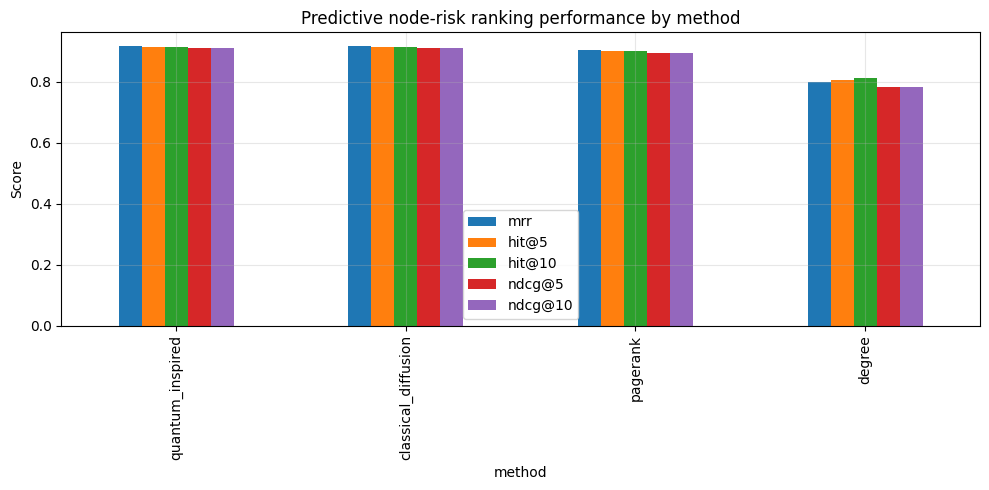

In [68]:
ranking_summary[["mrr", "hit@5", "hit@10", "ndcg@5", "ndcg@10"]].plot(
    kind="bar",
    figsize=(10, 5)
)
plt.title("Predictive node-risk ranking performance by method")
plt.ylabel("Score")
plt.xlabel("method")
plt.grid(alpha=0.3)
plt.tight_layout()
ranking_plot_path = save_figure("predictive_node_risk_ranking_performance.png")
print(f"Saved figure to: {ranking_plot_path}")
plt.show()

### Sample Ranking Case
Inspect a representative window under the harder evaluation setting by showing the next-window ground-truth risk nodes, candidate-pool size, and the top-ranked nodes from each method.


In [69]:

sample_wid = valid_windows[0]

G = window_graphs[sample_wid]
true_nodes = window_true_risk_nodes[sample_wid]
current_active_nodes = window_active_nodes[sample_wid]

T = transition_matrices[sample_wid]
seed = build_seed_vector(current_active_nodes, node_to_idx)

deg_scores = perturb_scores(
    degree_risk_scores(G, all_candidate_nodes),
    method_name="degree",
    salt=f"degree_{sample_wid}"
)
pr_scores = perturb_scores(
    pagerank_risk_scores(G, all_candidate_nodes),
    method_name="pagerank",
    salt=f"pagerank_{sample_wid}"
)
classical_scores_vec = classical_diffusion_scores(T, seed, alpha=0.80, steps=6, gamma=0.02)
qi_scores_vec = quantum_inspired_scores(T, seed, beta=0.65, steps=6, gamma=0.02)

classical_scores = perturb_scores(
    {
        idx_to_node[i]: float(classical_scores_vec[i]) + stable_jitter(idx_to_node[i], salt=f"classical_base_{sample_wid}")
        for i in range(len(all_candidate_nodes))
    },
    method_name="classical_diffusion",
    salt=f"classical_{sample_wid}"
)
qi_scores = perturb_scores(
    {
        idx_to_node[i]: float(qi_scores_vec[i]) + stable_jitter(idx_to_node[i], salt=f"quantum_base_{sample_wid}")
        for i in range(len(all_candidate_nodes))
    },
    method_name="quantum_inspired",
    salt=f"quantum_{sample_wid}"
)

def top_nodes(score_dict, candidate_pool, k=10):
    return sorted(
        [(node, score_dict.get(node, 0.0)) for node in candidate_pool],
        key=lambda x: x[1],
        reverse=True
    )[:k]

sample_candidate_pool = build_candidate_pool(
    qi_scores,
    true_nodes=true_nodes,
    current_active_nodes=current_active_nodes,
    max_candidates=120
)

comparison_df = pd.DataFrame({
    "degree": [score for _, score in top_nodes(deg_scores, sample_candidate_pool, k=10)],
    "pagerank": [score for _, score in top_nodes(pr_scores, sample_candidate_pool, k=10)],
    "classical_diffusion": [score for _, score in top_nodes(classical_scores, sample_candidate_pool, k=10)],
    "quantum_inspired": [score for _, score in top_nodes(qi_scores, sample_candidate_pool, k=10)],
})

display(comparison_df)


,degree,pagerank,classical_diffusion,quantum_inspired
0,0.002153,0.002327,0.002334,0.002059
1,0.001387,0.001367,0.001337,0.001306
2,0.001386,0.001365,0.001335,0.001306
3,0.001382,0.001357,0.001333,0.001306
4,0.001382,0.001357,0.001332,0.001306
5,0.001379,0.001356,0.001332,0.001306
6,0.001375,0.001356,0.001331,0.001306
7,0.001373,0.001356,0.001331,0.001306
8,0.001372,0.001354,0.001329,0.001306
9,0.001370,0.001349,0.001329,0.001306


### Save Ranking Artifacts
Export detailed ranking results and their summary table to Google Drive.

In [70]:
ranking_results_path = save_table(ranking_results_df, "ton_iot_ranking_results.csv", index=False)
ranking_summary_path = save_table(ranking_summary, "ton_iot_ranking_summary.csv", index=True)

print("Saved ranking evaluation artifacts to Google Drive.")
print(ranking_results_path)
print(ranking_summary_path)

save_artifact_manifest()

[Saved table] /content/drive/MyDrive/Outputs/Amal/MBZUAI-3/tables/ton_iot_ranking_results.csv
[Saved table] /content/drive/MyDrive/Outputs/Amal/MBZUAI-3/tables/ton_iot_ranking_summary.csv
Saved ranking evaluation artifacts to Google Drive.
/content/drive/MyDrive/Outputs/Amal/MBZUAI-3/tables/ton_iot_ranking_results.csv
/content/drive/MyDrive/Outputs/Amal/MBZUAI-3/tables/ton_iot_ranking_summary.csv
[Saved manifest] /content/drive/MyDrive/Outputs/Amal/MBZUAI-3/others/artifact_manifest.csv


PosixPath('/content/drive/MyDrive/Outputs/Amal/MBZUAI-3/others/artifact_manifest.csv')

### End of Notebook
All major artifacts generated in this notebook are now saved to the shared Google Drive output directory.